# <img style="float: left; padding-right: 15px; width: 35px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> CS 1090B: Advanced Topics in Data Science

# Reducing Hallucination in Legal RAG Chatbots: A Comparative Study of Deep Learning Retrieval Architectures

**Harvard University**<br/>
**Spring 2026**<br/>
**Instructors**: Pavlos Protopapas, Kevin Rader, Chris Gumb

**Project Group #43**<br/>
**Assigned Group's Teaching Fellow**: Zac Sardi-Santos<br/>
**Author:** Alex Oort Alonso, Allan Korir, Phong Le, and Brit Biddle<br/>

<hr style="height:2pt">

## MS2: Data Wrangling and Project Redefinition [3/27-4/10]

In [1]:
# Cell 1: Environment Setup & GPU Verification (TDD)
# Project: HallucinationLegalRAGChatbots
#
# Purpose
# -------
# One-time environment gate for the Harvard ODD GPU cluster notebook.
# Locates the project root, loads .env (TARGET_GPU_COUNT, reproducibility
# flags), configures deterministic training via src/repro.configure(),
# then runs the full TDD environment contract + preflight hard gate
# before any expensive GPU work begins.
#
# What it does
# ------------
# Step 0 — Project root + PATH (must be FIRST — before torch import):
#   1. Walks up from cwd until pyproject.toml is found (idempotent —
#      safe to re-run without drifting past root).
#   2. Prepends .venv/bin to PATH so subprocess calls to venv CLI tools
#      (dvc, uv, pytest) resolve correctly — Jupyter kernel inherits a
#      minimal PATH that excludes the venv's bin dir.
#   3. Loads .env via dotenv so preflight sees TARGET_GPU_COUNT,
#      TARGET_VRAM_GB_MIN, PYTHONHASHSEED, CUBLAS_WORKSPACE_CONFIG,
#      TOKENIZERS_PARALLELISM (override=False — repro.configure wins).
#   4. Calls src.repro.configure() — sets PYTHONHASHSEED, CUBLAS config,
#      TOKENIZERS_PARALLELISM, torch.use_deterministic_algorithms,
#      cuDNN flags, and seeds all RNGs. Guarantees notebook/CLI parity.
#
# Step 1 — Environment contract + preflight:
#   5. run_environment_checks() — TDD RED→GREEN gate: imports every
#      REQUIRED_DEPS entry, verifies version constraints, checks CUDA
#      availability, VRAM floor, and cross-package compatibility.
#   6. run_preflight_checks() — hard gate validating 9 conditions:
#      GPU count (exact match with TARGET_GPU_COUNT), compute cap,
#      VRAM, torch CUDA runtime, disk space, src/repro.py integrity,
#      repro_cfg dict, torch determinism flags, OS env vars, uv.lock.
#      Raises PreflightError with actionable message on any failure.
#   7. Logs repro config summary and verified environment table.
#
# Clean Code: Thin orchestration. All logic in src/environment.py.
# No side effects on import — checks wrapped in run_environment_checks().
#
# Reproducibility: src/repro.configure() MUST be called first — before any
# import of torch, transformers, or other ML libraries. This guarantees
# notebook/CLI parity: identical PYTHONHASHSEED, CUBLAS_WORKSPACE_CONFIG,
# TOKENIZERS_PARALLELISM, torch.use_deterministic_algorithms, and cuDNN flags
# regardless of whether the code runs in JupyterLab or from the CLI.
# See src/repro.py for full rationale.
#
# Failure isolation: run_preflight_checks() is a hard gate that validates ALL
# critical preconditions BEFORE any expensive GPU training begins. This prevents
# wasted GPU hours from misconfigured environments discovered mid-run.
# If preflight fails, the notebook raises immediately with an actionable message.
#
# Harvard cluster context
# -----------------------
# The notebook runs on the HallucinationLegalRAG Jupyter kernel, which IS
# .venv/bin/python (registered by setup.sh). All imports execute directly
# in the pinned venv — no subprocess-via-.venv wrapper needed (unlike the
# Colab version). TARGET_GPU_COUNT is resolved dynamically at setup time
# from CUDA_VISIBLE_DEVICES (or nvidia-smi count) and written to .env,
# so the same notebook works on 1-GPU SLURM jobs and 4-GPU interactive nodes.
#
# Runtime
# -------
# ~25-30s (dominated by dependency import verification and GPU preflight).
import os
import sys
from pathlib import Path

# Locate project root by walking up until pyproject.toml is found.
# Idempotent: safe to re-run the cell without drifting further up.
_here = Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), None)
assert _root is not None, f"pyproject.toml not found at or above {_here}"
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

# Prepend .venv/bin to PATH so subprocess calls to venv CLI tools (dvc, uv,
# pytest, etc.) resolve correctly. Jupyter kernel inherits a minimal PATH
# that excludes the venv's bin dir even though the kernel's Python IS the
# venv's interpreter.
_venv_bin = str(_root / ".venv" / "bin")
if _venv_bin not in os.environ["PATH"]:
    os.environ["PATH"] = f"{_venv_bin}:{os.environ['PATH']}"

# Load .env so preflight sees TARGET_GPU_COUNT, TARGET_VRAM_GB_MIN,
# PYTHONHASHSEED, CUBLAS_WORKSPACE_CONFIG, TOKENIZERS_PARALLELISM.
# override=False → repro.configure() still wins for repro-critical vars.
from dotenv import load_dotenv
load_dotenv(_root / ".env", override=False)

from src.repro import configure as _configure_repro
repro_cfg = _configure_repro(verbose=True)
# --- Step 1: Remaining imports (torch now imported safely after repro config) ---
import logging
from src.environment import (
    REQUIRED_DEPS,
    get_environment_summary,
    run_environment_checks,
    run_preflight_checks,
)
from src.timer import cell_timer
logger = logging.getLogger("cell1")
logger.setLevel(logging.INFO)
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("  %(message)s"))
    logger.addHandler(handler)
with cell_timer("Cell 1 — Environment Setup & GPU Verification", logger=logger):
    # --- TDD Contract ---
    logger.info("=" * 60)
    logger.info("  TDD RED→GREEN: Environment Contract")
    logger.info("=" * 60)
    assert run_environment_checks(logger=logger), "Environment contract violated"
    # --- Preflight Gate (hard stop before any expensive training) ---
    # Validates: GPU count/name/VRAM, disk space, repro config integrity,
    # uv.lock hash match, and src/repro.py presence.
    # Raises PreflightError with actionable message on any failure.
    logger.info(f"\n{'=' * 60}")
    logger.info("  Preflight Checks — Failure Isolation Gate")
    logger.info("=" * 60)
    run_preflight_checks(logger=logger, repro_cfg=repro_cfg)
    # --- Repro Config Summary ---
    logger.info(f"\n{'=' * 60}")
    logger.info("  Reproducibility Config (src/repro.configure)")
    logger.info("=" * 60)
    for k, v in repro_cfg.items():
        logger.info(f"  {k:<36} {v}")
    # --- Environment Summary ---
    env = get_environment_summary()
    logger.info(f"\n{'=' * 60}")
    logger.info("  Verified Environment")
    logger.info("=" * 60)
    for pkg, constraint in REQUIRED_DEPS.items():
        logger.info(f"  {pkg:<16} {env[pkg]:<12} (requires {constraint or 'any'})")
    logger.info(f"  {'GPU':<16} {env['gpu']}")
    logger.info(f"  {'GPU Memory':<16} {env['gpu_memory_gb']} GB")
    logger.info(f"  {'CUDA':<16} {env['cuda']}")
    logger.info("\n✓ Environment ready — all preflight checks passed, safe to proceed")

    TDD RED→GREEN: Environment Contract


  [repro] Reproducibility configured:
    PYTHONHASHSEED=0
    CUBLAS_WORKSPACE_CONFIG=:4096:8
    TOKENIZERS_PARALLELISM=false
    deterministic_algorithms=True
    cudnn_benchmark=False
    cudnn_deterministic=True
    random_seed=0
    torch.cuda.manual_seed_all(0) → 1 GPU(s)


  ✓ PASS: Every required dependency must be importable and meet version constraints
  ✓ PASS: CUDA GPU must be detected for training
  ✓ PASS: GPU must have at least 10GB VRAM for transformer fine-tuning
  ✓ PASS: PyTorch must be compiled with CUDA support
  ✓ PASS: Cross-dependency version constraints must be satisfied
  
    Preflight Checks — Failure Isolation Gate
  ✓ PASS: GPU count 1 == TARGET_GPU_COUNT=1 (exact)
  ✓ PASS: GPU[0] NVIDIA L4 | cap (8, 9) | 23.7GB
  ✓ PASS: torch CUDA runtime 11.7
  ✓ PASS: Disk 9223360478.4GB free
  ✓ PASS: src/repro.py importable
  ✓ PASS: repro_cfg['PYTHONHASHSEED'] = '0'
  ✓ PASS: repro_cfg['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
  ✓ PASS: repro_cfg['TOKENIZERS_PARALLELISM'] = 'false'
  ✓ PASS: repro_cfg['deterministic_algorithms'] = True
  ✓ PASS: repro_cfg['cudnn_benchmark'] = False
  ✓ PASS: repro_cfg['cudnn_deterministic'] = True
  ✓ PASS: torch runtime state — deterministic
  ✓ PASS: os.environ['PYTHONHASHSEED'] = '0'
  ✓ PASS: os.environ['C

In [2]:
# Cell 2: Verify CL bulk data directory on Harvard cluster filesystem
"""
Purpose
-------
Ensures the CourtListener bulk CSV archive directory exists and reports
any existing archives with sizes, so warm-start runs confirm data
presence before the download cell attempts S3 fetches. Also checks
available disk space — the full CL bulk snapshot requires ~60 GB.

What it does
------------
1. Creates data/raw/cl_bulk/ if it does not already exist (idempotent).
2. Reports filesystem free/total space so the user can confirm
   sufficient capacity before attempting the CL bulk download.
3. Lists any existing .csv.bz2 archives with sizes — useful to confirm
   a warm-start run already has the bulk archives from a prior session.

Filesystem layout
-----------------
data/raw/cl_bulk/
    courts-2025-12-31.csv.bz2          (~1 KB)
    dockets-2025-12-31.csv.bz2         (~4.9 GB)
    opinion-clusters-2025-12-31.csv.bz2 (~2.5 GB)
    opinions-2025-12-31.csv.bz2        (~53.7 GB)

Harvard cluster home directories persist across sessions, so archives
survive runtime resets without Drive mounts or symlinks. The download
cell writes directly into this directory.

Runtime
-------
<1s (directory creation + stat calls only).
"""
import shutil, time
from pathlib import Path

_t_start = time.perf_counter()

cl_bulk = Path("data/raw/cl_bulk")
cl_bulk.mkdir(parents=True, exist_ok=True)
print(f"cl_bulk dir: {cl_bulk.resolve()}")

total, used, free = shutil.disk_usage(cl_bulk)
print(f"filesystem free: {free/1e9:.1f} GB / total: {total/1e9:.1f} GB")

archives = sorted(cl_bulk.glob("*.csv.bz2"))
if archives:
    print(f"existing archives ({len(archives)}):")
    for p in archives:
        print(f"  {p.name}  {p.stat().st_size/1e9:.2f} GB")
else:
    print("no archives yet — Cell 5 bulk_download will fetch from CourtListener")

print(f"⏱ Cell 2: Verify CL bulk data directory on Harvard cluster filesystem completed in {time.perf_counter() - _t_start:.1f}s")

cl_bulk dir: /shared/home/phl690/cs1090b_HallucinationLegalRAGChatbots/data/raw/cl_bulk
filesystem free: 9223360478.4 GB / total: 9223372036.9 GB
existing archives (4):
  courts-2025-12-31.csv.bz2  0.00 GB
  dockets-2025-12-31.csv.bz2  4.88 GB
  opinion-clusters-2025-12-31.csv.bz2  2.45 GB
  opinions-2025-12-31.csv.bz2  53.70 GB
⏱ Cell 2: Verify CL bulk data directory on Harvard cluster filesystem completed in 0.0s


In [3]:
# Cell 3: CourtListener bulk CSV download — filesystem-persistent, skip if present
"""
Purpose
-------
Downloads the 4 CourtListener bulk CSV archives (courts, dockets,
opinion-clusters, opinions) into data/raw/cl_bulk/. Idempotent: if all
4 archives are already present, skips the download entirely. Otherwise
uses the pinned 2025-12-31 snapshot (matching the pipeline cell's
manifest) via config.pinned_files to download only what's missing.

What it does
------------
1. Instantiates PipelineConfig with pinned 2025-12-31 S3 object keys.
2. Checks which of {courts-, dockets-, opinion-clusters-, opinions-}
   archives already exist in cfg.bulk_dir.
3. If all 4 present: logs sizes and skips — no network I/O.
4. Otherwise: uses cfg.pinned_files (no S3 discovery), then calls
   download_bulk_csvs() for the missing set, logs destination paths.

Snapshot pinning (2025-12-31)
-----------------------------
Pinning to 2025-12-31 matches the pre-processed shards + manifest
already on the Harvard cluster filesystem. Without pinning, S3
discovery finds a newer snapshot and triggers a cold re-extraction.
With pinning, the pipeline cell's fast-path sees matching source_files
in the manifest and skips immediately.

Filesystem layout
-----------------
data/raw/cl_bulk/
    courts-2025-12-31.csv.bz2          (~1 KB)
    dockets-2025-12-31.csv.bz2         (~4.9 GB)
    opinion-clusters-2025-12-31.csv.bz2 (~2.5 GB)
    opinions-2025-12-31.csv.bz2        (~53.7 GB)

Harvard cluster home directories persist across sessions, so archives
survive runtime resets without Drive mounts or symlinks. All imports
run directly in the kernel (which IS .venv/bin/python) — no subprocess
wrapper needed.

Runtime
-------
Warm start (all archives present): <1s (directory scan + size log).
Cold start (full download): ~15-40 min depending on S3 throughput and
the total archive size (~60 GB compressed).
"""
import logging, time
from src.config import PipelineConfig
from src.bulk_download import download_bulk_csvs

_t_start = time.perf_counter()
logging.basicConfig(level=logging.INFO, format="  %(message)s")
log = logging.getLogger("bulk")

cfg = PipelineConfig(
    pinned_courts="bulk-data/courts-2025-12-31.csv.bz2",
    pinned_dockets="bulk-data/dockets-2025-12-31.csv.bz2",
    pinned_clusters="bulk-data/opinion-clusters-2025-12-31.csv.bz2",
    pinned_opinions="bulk-data/opinions-2025-12-31.csv.bz2",
)
cfg.bulk_dir.mkdir(parents=True, exist_ok=True)
log.info("Snapshot: pinned 2025-12-31 (matches manifest)")

need = {"courts-", "dockets-", "opinion-clusters-", "opinions-"}
have = {p.name for p in cfg.bulk_dir.glob("*.csv.bz2")}
matched = {lbl for lbl in need if any(n.startswith(lbl) for n in have)}

if matched == need:
    log.info(f"All 4 bulk CSVs already present in {cfg.bulk_dir} — skipping")
    for p in sorted(cfg.bulk_dir.glob("*.csv.bz2")):
        log.info(f"  {p.name}  {p.stat().st_size / 1e9:.2f} GB")
else:
    log.info(f"Missing: {sorted(need - matched)}")
    latest = cfg.pinned_files
    for label, info in latest.items():
        log.info(f"  {label:<10} {info['key']}")
    paths = download_bulk_csvs(latest, config=cfg, logger=log)
    for label, p in paths.items():
        log.info(f"  {label:<10} -> {p}")

print(f"⏱ Cell 3: CourtListener bulk CSV download — filesystem-persistent, skip if present completed in {time.perf_counter() - _t_start:.1f}s")

  Snapshot: pinned 2025-12-31 (matches manifest)
  All 4 bulk CSVs already present in data/raw/cl_bulk — skipping
    courts-2025-12-31.csv.bz2  0.00 GB
    dockets-2025-12-31.csv.bz2  4.88 GB
    opinion-clusters-2025-12-31.csv.bz2  2.45 GB
    opinions-2025-12-31.csv.bz2  53.70 GB


⏱ Cell 3: CourtListener bulk CSV download — filesystem-persistent, skip if present completed in 0.0s


In [4]:
# Cell 4: Filter chain + extraction + manifest (Harvard filesystem-persistent shards)
"""
Purpose
-------
End-to-end Stage 1-2 data pipeline: pinned snapshot → filter chain →
extract → manifest → TDD contract tests. Produces the filesystem-
persistent NDJSON shards that downstream embedding, training, and
evaluation cells operate on.

Fast-path behavior
------------------
If manifest.json and all referenced shards are already present in the
shard directory (e.g. pre-processed on a prior Harvard ODD GPU Cluster
L4 session), run_pipeline() returns immediately without re-running any
stage. Otherwise runs the full pipeline:
  1. Pinned snapshot — use cfg.pinned_files (no S3 discovery)
  2. Download        — fetch missing archives into data/raw/cl_bulk
  3. Filter chain    — court → docket → cluster → opinion joins,
                       restricted to federal appellate circuits
  4. Extract         — per-opinion text extraction (html/plain/xml),
                       quarantine for per-row failures
  5. Manifest        — write manifest.json with provenance
                       (git rev, snapshot id, court distribution, stats)
  6. Contract tests  — validate_pipeline() runs TDD invariants
                       against the manifest and a sample of shards

Snapshot pinning (2025-12-31)
-----------------------------
PipelineConfig is pinned to the 2025-12-31 CL bulk snapshot, which
matches the pre-processed shards + manifest already on the Harvard
cluster filesystem. Without pinning, run_pipeline calls
discover_latest_bulk_files() which finds a newer snapshot on S3, sees
the manifest's source_files don't match, and triggers a cold
re-extraction. With pinning, the fast-path check succeeds immediately
and the cell returns in <30s.

Filesystem layout
-----------------
data/raw/cl_federal_appellate_bulk/
    shard_0000.jsonl ... shard_NNNN.jsonl
    manifest.json

Harvard cluster home directories persist across sessions, so no
Drive mount or symlink is needed — shards survive runtime resets.

Post-manifest infrastructure hooks
-----------------------------------
Three hooks (all TDD-covered in src/):
  - src.dvc_tracking   : version the shard directory with DVC
  - src.dataset_card   : emit HF Hub README.md from the manifest
  - src.data_contracts : statistical gates (row floor, court balance,
                         text length distribution)

Runtime
-------
Warm start (shards + manifest valid, pinned): ~10-30s (manifest parse +
contract tests on sampled shards).
Cold start (full pipeline from pinned snapshot): ~30-90 min on the
Harvard ODD L4 node (48-core AMD EPYC, 182 GB RAM).
"""
import logging, sys
from src.config import PipelineConfig
from src.data_contracts import run_all_contracts
from src.dataset_card import write_dataset_card
from src.dvc_tracking import DVCTrackingError, track_shard_directory
from src.pipeline import run_pipeline, validate_pipeline
from src.timer import cell_timer

def _get_cell_logger():
    lg = logging.getLogger("cell_pipeline")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg

logger = _get_cell_logger()
cfg = PipelineConfig(
    pinned_courts="bulk-data/courts-2025-12-31.csv.bz2",
    pinned_dockets="bulk-data/dockets-2025-12-31.csv.bz2",
    pinned_clusters="bulk-data/opinion-clusters-2025-12-31.csv.bz2",
    pinned_opinions="bulk-data/opinions-2025-12-31.csv.bz2",
)

with cell_timer("Cell 4: Pipeline (filter + extract + manifest)", logger=logger):
    logger.info("=" * 60)
    logger.info("  run_pipeline (pinned 2025-12-31; fast-path if manifest + shards valid)")
    logger.info("=" * 60)
    manifest = run_pipeline(config=cfg, logger=logger)

    logger.info("\n" + "=" * 60)
    logger.info("  validate_pipeline (TDD contract tests)")
    logger.info("=" * 60)
    validate_pipeline(config=cfg, manifest_data=manifest, logger=logger, shard_strategy="sample")
    logger.info("OK contract tests passed")

    logger.info("\n" + "=" * 60)
    logger.info("  DVC tracking (src.dvc_tracking)")
    logger.info("=" * 60)
    try:
        track_shard_directory(cfg.shard_dir, repo_root=".", push=False)
        logger.info("  OK shard_dir versioned (or already tracked)")
    except DVCTrackingError as e:
        logger.info(f"  SKIP dvc: {e}")

    logger.info("\n" + "=" * 60)
    logger.info("  HF dataset card (src.dataset_card)")
    logger.info("=" * 60)
    card_path = write_dataset_card(manifest, cfg.shard_dir)
    logger.info(f"  OK wrote {card_path}")

    logger.info("\n" + "=" * 60)
    logger.info("  Statistical data contracts (src.data_contracts)")
    logger.info("=" * 60)
    for r in run_all_contracts(manifest, strict=False):
        status = "PASS" if r.passed else "FAIL"
        logger.info(f"  {r.name:<28} {status} - {r.message}")

    logger.info("\n" + "=" * 60)
    logger.info("  Summary")
    logger.info("=" * 60)
    logger.info(f"  snapshot: {manifest['source_files']['opinions']}")
    logger.info(f"  git_rev:  {manifest['run_metadata']['git_revision'][:12]}")
    logger.info(f"  shards:   {manifest['num_shards']}")
    logger.info(f"  cases:    {manifest['num_cases']:,}")
    logger.info(f"  scanned:  {manifest.get('scanned', 0):,}")
    logger.info(f"  circuits: {len(manifest.get('court_distribution', {}))}")
    tls = manifest.get("text_length_stats", {})
    if tls:
        logger.info(f"  text len: mean={tls.get('mean', 0):,} median={tls.get('median', 0):,} p95={tls.get('p95', 0):,}")

    run_pipeline (pinned 2025-12-31; fast-path if manifest + shards valid)
  ✓ Already complete: 1,465,484 cases, 159 shards verified
  
    validate_pipeline (TDD contract tests)
  ✓ PASS: Shard directory must exist
  ✓ PASS: Manifest must exist
  ✓ PASS: At least one shard present
  ✓ PASS: Sufficient opinions
  ✓ PASS: Valid JSON
  ✓ PASS: Text present
  ✓ PASS: Text substantive
  ✓ PASS: Provenance metadata
  ✓ PASS: Raw + normalized text + flags
  ✓ PASS: Text source tracked
  ✓ PASS: Multiple circuits
  ✓ PASS: Schema consistent
  ✓ PASS: Checksums match
  OK contract tests passed
  
    DVC tracking (src.dvc_tracking)
    SKIP dvc: dvc add failed (exit 1): ERROR: bad DVC file name 'data/raw/cl_federal_appellate_bulk.dvc' is git-ignored.
  
    HF dataset card (src.dataset_card)
    OK wrote data/raw/cl_federal_appellate_bulk/README.md
  
    Statistical data contracts (src.data_contracts)
    row_count_floor              PASS - 1,465,484 >= 10,000
    court_balance              

In [5]:
# Cell 5 (Harvard ODD adaptation): Filter chain + extraction + manifest
"""
Purpose
-------
End-to-end Stage 1-2 data pipeline: pinned snapshot → filter chain →
extract → manifest → TDD contract tests. Produces the NDJSON shards
that downstream MS3 EDA and baseline cells operate on.
Fast-path behavior
------------------
If manifest.json and all referenced shards are already present in
data/raw/cl_federal_appellate_bulk/ (pre-processed on this node's
prior session), run_pipeline() returns immediately without re-running
any stage. Otherwise runs the full pipeline:
  1. Pinned snapshot — use cfg.pinned_files (no S3 discovery)
  2. Download        — fetch missing archives into data/raw/cl_bulk
  3. Filter chain    — court → docket → cluster → opinion joins,
                       restricted to federal appellate circuits
  4. Extract         — per-opinion text extraction (html/plain/xml),
                       quarantine for per-row failures
  5. Manifest        — write manifest.json with provenance
                       (git rev, snapshot id, court distribution, stats)
  6. Contract tests  — validate_pipeline() runs TDD invariants
                       against the manifest and a sample of shards
Snapshot pinning (2025-12-31)
-----------------------------
PipelineConfig is pinned to the 2025-12-31 CL bulk snapshot, which
matches the pre-processed shards + manifest already on disk from the
prior ODD run (git rev 780ff292, 1,465,484 opinions, 159 shards).
Without pinning, run_pipeline calls discover_latest_bulk_files() which
finds a newer snapshot on S3, sees the manifest's source_files don't
match, and triggers a multi-hour cold re-extraction. With pinning, the
fast-path check succeeds immediately and the cell returns in <30s.
Harvard ODD GPU cluster layout
------------------------------
data/raw/cl_federal_appellate_bulk/
    shard_0000.jsonl ... shard_0158.jsonl   (159 shards, ~43 GB)
    manifest.json                            (schema v2, git SHA, stats)
    checkpoint.json                          (ingestion progress)
No Drive symlink needed — shards are on the cluster's local filesystem.
Post-manifest infrastructure hooks (all TDD-covered in src/):
  - src.dvc_tracking   : version the shard directory with DVC
                         (intentionally a no-op here — the 43 GB CL
                         corpus is reproducible from CourtListener's
                         public S3; only LePaRD is DVC-tracked in
                         project S3, per README "Data Storage &
                         Provenance Summary")
  - src.dataset_card   : emit HF Hub README.md from the manifest
  - src.data_contracts : statistical gates (row floor, court balance,
                         text length distribution)
Runtime
-------
Warm start (shards + manifest valid, pinned): ~20-40s (manifest parse
+ sampled-shard contract tests over NFS-mounted disk).
Cold start: not expected on this node — if triggered, will re-ingest
from data/raw/cl_bulk/ (the 57 GB pinned CSVs must be present).
"""
import logging
import sys
from pathlib import Path

from src.config import PipelineConfig
from src.data_contracts import run_all_contracts
from src.dataset_card import write_dataset_card
from src.dvc_tracking import DVCTrackingError, track_shard_directory
from src.pipeline import run_pipeline, validate_pipeline
from src.timer import cell_timer


def _get_cell5_logger() -> logging.Logger:
    lg = logging.getLogger("cell5")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg


logger = _get_cell5_logger()

# Sanity-check that the shard directory exists on this node before invoking
# the pipeline; bail out with a clear error message if not (saves 30+ min
# of opaque pipeline failure on a fresh clone).
shard_dir = Path("data/raw/cl_federal_appellate_bulk")
if not shard_dir.exists():
    raise RuntimeError(
        f"Expected shard dir {shard_dir} not found on this node. "
        "Re-ingest via scripts/bulk_download.py at the pinned git SHA "
        "(see README 'Data Storage & Provenance Summary') before running Cell 5."
    )

cfg = PipelineConfig(
    pinned_courts="bulk-data/courts-2025-12-31.csv.bz2",
    pinned_dockets="bulk-data/dockets-2025-12-31.csv.bz2",
    pinned_clusters="bulk-data/opinion-clusters-2025-12-31.csv.bz2",
    pinned_opinions="bulk-data/opinions-2025-12-31.csv.bz2",
)

with cell_timer("Cell 5 - Pipeline (filter + extract + manifest)", logger=logger):
    logger.info("=" * 60)
    logger.info("  run_pipeline (pinned 2025-12-31; fast-path if manifest + shards valid)")
    logger.info("=" * 60)
    manifest = run_pipeline(config=cfg, logger=logger)

    logger.info("\n" + "=" * 60)
    logger.info("  validate_pipeline (TDD contract tests)")
    logger.info("=" * 60)
    validate_pipeline(
        config=cfg,
        manifest_data=manifest,
        logger=logger,
        shard_strategy="sample",
    )
    logger.info("OK contract tests passed")

    # --- Post-manifest infrastructure hooks ---
    logger.info("\n" + "=" * 60)
    logger.info("  DVC tracking (src.dvc_tracking)")
    logger.info("=" * 60)
    # NB: Per README "Data Storage & Provenance Summary", the 43 GB CL
    # corpus is intentionally NOT mirrored in project S3 — reproducibility
    # is guaranteed by the pinned git SHA + manifest.json against
    # CourtListener's public S3. track_shard_directory either no-ops or
    # registers the directory locally depending on repo state.
    try:
        track_shard_directory(cfg.shard_dir, repo_root=".", push=False)
        logger.info("  OK shard_dir versioned (or already tracked)")
    except DVCTrackingError as e:
        logger.info(f"  SKIP dvc: {e}")

    logger.info("\n" + "=" * 60)
    logger.info("  HF dataset card (src.dataset_card)")
    logger.info("=" * 60)
    card_path = write_dataset_card(manifest, cfg.shard_dir)
    logger.info(f"  OK wrote {card_path}")

    logger.info("\n" + "=" * 60)
    logger.info("  Statistical data contracts (src.data_contracts)")
    logger.info("=" * 60)
    for r in run_all_contracts(manifest, strict=False):
        status = "PASS" if r.passed else "FAIL"
        logger.info(f"  {r.name:<28} {status} - {r.message}")

    # --- Summary ---
    logger.info("\n" + "=" * 60)
    logger.info("  Summary")
    logger.info("=" * 60)
    logger.info("  snapshot: %s" % manifest["source_files"]["opinions"])
    logger.info("  git_rev:  %s" % manifest["run_metadata"]["git_revision"][:12])
    logger.info("  shards:   %d" % manifest["num_shards"])
    logger.info("  cases:    %s" % format(manifest["num_cases"], ","))
    logger.info("  scanned:  %s" % format(manifest.get("scanned", 0), ","))
    logger.info("  circuits: %d" % len(manifest.get("court_distribution", {})))
    tls = manifest.get("text_length_stats", {})
    if tls:
        logger.info(
            "  text len: mean=%s median=%s p95=%s"
            % (
                format(tls.get("mean", 0), ","),
                format(tls.get("median", 0), ","),
                format(tls.get("p95", 0), ","),
            )
        )

    run_pipeline (pinned 2025-12-31; fast-path if manifest + shards valid)
  ✓ Already complete: 1,465,484 cases, 159 shards verified
  
    validate_pipeline (TDD contract tests)
  ✓ PASS: Shard directory must exist
  ✓ PASS: Manifest must exist
  ✓ PASS: At least one shard present
  ✓ PASS: Sufficient opinions
  ✓ PASS: Valid JSON
  ✓ PASS: Text present
  ✓ PASS: Text substantive
  ✓ PASS: Provenance metadata
  ✓ PASS: Raw + normalized text + flags
  ✓ PASS: Text source tracked
  ✓ PASS: Multiple circuits
  ✓ PASS: Schema consistent
  ✓ PASS: Checksums match
  OK contract tests passed
  
    DVC tracking (src.dvc_tracking)
    SKIP dvc: dvc add failed (exit 1): ERROR: bad DVC file name 'data/raw/cl_federal_appellate_bulk.dvc' is git-ignored.
  
    HF dataset card (src.dataset_card)
    OK wrote data/raw/cl_federal_appellate_bulk/README.md
  
    Statistical data contracts (src.data_contracts)
    row_count_floor              PASS - 1,465,484 >= 10,000
    court_balance              

In [6]:
# Cell 5.5 (Harvard ODD adaptation): Upstream NaN repair
"""
Purpose
-------
Repairs bare NaN/Infinity tokens in Cell 5's NDJSON shards so Cell 6's
Polars scan_ndjson fast-path works on all shards. Python's json writer
emits bare NaN by default (non-spec JSON); Polars' strict simd-json
parser rejects these with TapeError, forcing a slower fallback that
silently drops records. This cell fixes the shards upstream of Cell 6
so all records are loaded via Polars' fast path.
Three-step flow
---------------
1. Audit before repair: scans all shards, identifies contaminated ones
   (typically 8-9 of 159 for the CL federal appellate corpus), reports
   pre-repair verdict and nan_lines count.
2. Repair: runs scripts/audit_jsonl_nan.py --fix --parallel-repair
   --validate. Semantic repair (json.loads with parse_constant intercept
   → recursive NaN→None walk → json.dumps(allow_nan=False)) so legal
   text containing literal "NaN" inside quoted strings is never
   corrupted. Streaming (O(1) RAM regardless of shard size), atomic
   rename with .bak backup, idempotent, Polars-validated post-repair.
3. Re-audit: confirms post-repair verdict is CLEAN and clean_pct=100.0.
   Raises RuntimeError on anything other than CLEAN.
Why this cell exists
--------------------
Without it, Cell 6 emits Polars TapeError WARNINGs and loads only a
partial record set (silently dropping contaminated shards' contents).
With it, Cell 6 takes the fast path on all shards and loads the full
1,465,484-opinion corpus.
Harvard ODD GPU cluster runtime
-------------------------------
~3-6 min on the 48-core ODD node (audit ~30s × 2 per README + repair
~3-5 min over 159 shards). Idempotent re-runs after a first successful
repair complete in ~60s (audit still scans but finds nothing to fix).
"""
import json
import os
import pathlib
import re
import subprocess
import sys
import time


def _fmt_elapsed(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.1f}s"
    m, s = divmod(seconds, 60)
    if m < 60:
        return f"{int(m)}m {s:.1f}s"
    h, m = divmod(m, 60)
    return f"{int(h)}h {int(m)}m {s:.1f}s"


_t_start = time.perf_counter()

# No os.chdir — notebook kernel runs from repo root on ODD.
shard_dir = pathlib.Path("data/raw/cl_federal_appellate_bulk")
if not shard_dir.exists() or not any(shard_dir.glob("shard_*.jsonl")):
    raise RuntimeError(f"no shards under {shard_dir} — run Cell 5 first")


def _stream(cmd):
    env = {**os.environ, "PYTHONUNBUFFERED": "1"}
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        text=True,
        env=env,
    )
    lines = []
    for line in proc.stdout:
        sys.stdout.write(line)
        sys.stdout.flush()
        lines.append(line)
    proc.wait()
    return proc.returncode, "".join(lines)


def _extract_report(out: str) -> dict:
    # audit_jsonl_nan.py emits json.dumps(..., indent=2), so the top-level
    # object has '{' and '}' anchored at column 0. Match line-anchored braces
    # to avoid false matches on nested '{}' (e.g. empty "nan_fields": {}).
    match = re.search(r"^\{.*?^\}", out, re.MULTILINE | re.DOTALL)
    if not match:
        raise RuntimeError("could not locate JSON report in audit output")
    return json.loads(match.group(0))


print("=" * 60)
print("  Step 1: audit before repair")
print("=" * 60)
rc, out = _stream(
    [
        ".venv/bin/python",
        "scripts/audit_jsonl_nan.py",
        "--input-dir",
        str(shard_dir),
        "--json",
        "--emit-shard-ids",
    ]
)
if rc != 0:
    raise SystemExit(f"pre-repair audit failed with exit code {rc}")
pre_report = _extract_report(out)
print(f"\n  pre-repair verdict: {pre_report.get('gate_verdict')}")
print(f"  pre-repair nan_lines: {pre_report.get('nan_lines')}")

# Idempotent short-circuit: if already CLEAN, skip repair step.
if pre_report.get("gate_verdict") == "CLEAN" and pre_report.get("nan_lines", 0) == 0:
    print("\n" + "=" * 60)
    print("  Step 2: SKIP — shards already CLEAN (idempotent fast-path)")
    print("=" * 60)
    report = pre_report
else:
    print("\n" + "=" * 60)
    print("  Step 2: repair (semantic, parallel, Polars-validated)")
    print("=" * 60)
    rc, _ = _stream(
        [
            ".venv/bin/python",
            "scripts/audit_jsonl_nan.py",
            "--input-dir",
            str(shard_dir),
            "--fix",
            "--parallel-repair",
            "--validate",
        ]
    )
    if rc != 0:
        raise SystemExit(f"repair failed with exit code {rc}")

    print("\n" + "=" * 60)
    print("  Step 3: re-audit after repair (must be CLEAN)")
    print("=" * 60)
    rc, out = _stream(
        [
            ".venv/bin/python",
            "scripts/audit_jsonl_nan.py",
            "--input-dir",
            str(shard_dir),
            "--json",
        ]
    )
    if rc != 0:
        raise SystemExit(f"post-repair audit failed with exit code {rc}")
    report = _extract_report(out)
    if report.get("gate_verdict") != "CLEAN":
        raise RuntimeError(f"post-repair verdict not CLEAN: {report.get('gate_verdict')}")

print(
    f"\nOK repair complete — verdict: {report['gate_verdict']}, "
    f"clean_pct: {report['clean_pct']}, total_lines: {report['total_lines']:,}"
)

_elapsed = time.perf_counter() - _t_start
print(f"⏱ Cell 5.5 - Upstream NaN repair completed in {_fmt_elapsed(_elapsed)}")

  Step 1: audit before repair
[INFO] Scanning 159 shards using 48 CPU cores ...

auditing: 100%|██████████| 159/159 [00:16<00:00,  9.71shard/s]
{
  "total_lines": 1465484,
  "nan_lines": 0,
  "nonfinite_lines": 0,
  "string_sentinel_lines": 0,
  "decode_error_lines": 0,
  "nan_shards": 0,
  "total_shards": 159,
  "clean_pct": 100.0,
  "nan_fields": {},
  "gate_verdict": "CLEAN",
  "contaminated_shards": []
}

  pre-repair verdict: CLEAN
  pre-repair nan_lines: 0

  Step 2: SKIP — shards already CLEAN (idempotent fast-path)

OK repair complete — verdict: CLEAN, clean_pct: 100.0, total_lines: 1,465,484
⏱ Cell 5.5 - Upstream NaN repair completed in 19.0s


In [7]:
# Cell 6 (Harvard ODD adaptation): Dataset readiness probe — full-corpus Polars scan, 8 gates
"""
Purpose
-------
Dataset readiness gate for the CourtListener federal appellate corpus
ingested in Cell 5 and cleaned in Cell 5.5. Runs src.dataset_probe
(v2.5.11+, 303 contract tests, frozen ProbeConfig) as a full-corpus
Polars scan with 8 quality gates. Go/no-go check before Stage 3.
Gates evaluated
---------------
  schema — Pydantic schema validation on every record
  A7     — text_source breakdown (html vs plain_text vs xml distribution)
  A8     — text_length distribution (blocking — enforces min/max bounds)
  A9     — citation_count distribution (advisory)
  A11    — tokenizer-aware chunk count under BAAI/bge-m3 (blocking)
  A12    — citation anchor survival after text extraction (blocking)
  A13    — sentence density via spaCy (blocking)
  B6     — text_entropy distribution (advisory — detects degenerate text)
Blocking gates must PASS for the corpus to clear Stage 3. Advisory gates
surface warnings but do not fail the run.
HF_TOKEN
--------
Gate A11 downloads the BAAI/bge-m3 tokenizer from Hugging Face. The
model is public so a token is not strictly required, but Hugging Face
Hub emits a UserWarning when HF_TOKEN is unset. On Harvard ODD, the
token is loaded from .env via src.environment at notebook bootstrap
(see README "HF_TOKEN is required by this repo on the shared cluster").
Summary counts
--------------
dataset_probe v2.5.12 does not populate summary["passed_count"] or
summary["failed_blocking_count"], so this cell derives them directly
from report.gates as ground truth. Avoids the cosmetic "passed_count: 0"
bug seen in prior runs.
Performance
-----------
Full scan uses Polars scan_ndjson (memory-mapped, lazy). First run on a
cold corpus: ~7-9 min for 1.46M rows on the 48-core ODD node. Re-runs
are cheap (~30s) because Polars mmaps the shards. Requires Cell 5.5 to
have repaired any bare-NaN shards — otherwise contaminated shards fall
back to a slower Python path and some records are dropped.
Output
------
logs/dataset_probe_report.json — full ProbeReport dump (gates, summary,
provenance, per-gate evidence). Raises RuntimeError if any blocking
gate fails.
Runtime
-------
Full scan (cold): ~7-9 min on ODD 48-core node
Warm re-run:      ~30s
"""
import json
import logging
import os
import pathlib
import sys

from src.dataset_probe import ProbeConfig, run_probe
from src.timer import cell_timer

# HF_TOKEN is loaded from .env by src.environment at notebook bootstrap on
# Harvard ODD (required per README on the shared cluster). This fallback
# from dotenv is a safety net in case src.environment wasn't invoked yet.
if not os.environ.get("HF_TOKEN"):
    try:
        from dotenv import load_dotenv

        load_dotenv()
    except Exception:
        pass  # warning will appear but probe still runs — A11 uses a public model


def _get_cell6_logger() -> logging.Logger:
    lg = logging.getLogger("cell6")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg


logger = _get_cell6_logger()

shard_dir = pathlib.Path("data/raw/cl_federal_appellate_bulk")
out_path = pathlib.Path("logs/dataset_probe_report.json")
out_path.parent.mkdir(parents=True, exist_ok=True)

with cell_timer("Cell 6 - Dataset readiness probe", logger=logger):
    logger.info("=" * 60)
    logger.info("  run_probe (full-corpus Polars scan, 8 gates)")
    logger.info("=" * 60)
    logger.info("  shard_dir: %s" % shard_dir.resolve())

    probe_cfg = ProbeConfig()
    report = run_probe(
        data_dir=shard_dir,
        subset=1_465_484,  # full corpus
        output=out_path,  # run_probe writes report to this path
        full_scan=True,  # always True in v2.5.11+ (Polars mandatory)
        config=probe_cfg,
    )
    logger.info("  report -> %s" % out_path)

    logger.info("\n" + "=" * 60)
    logger.info("  Probe summary")
    logger.info("=" * 60)

    summary = (
        report.summary
        if isinstance(report.summary, dict)
        else report.summary.model_dump()
    )

    # Compute gate counts directly from report.gates — dataset_probe v2.5.12
    # does not populate summary["passed_count"] / summary["failed_blocking_count"],
    # so derive them from the per-gate results as ground truth.
    gate_items = [
        (name, gr if isinstance(gr, dict) else gr.model_dump())
        for name, gr in report.gates.items()
    ]
    total_gates = len(gate_items)
    passed_count = sum(1 for _, gr in gate_items if gr.get("pass"))
    failed_blocking = sum(
        1 for _, gr in gate_items
        if not gr.get("pass") and gr.get("severity") == "blocking"
    )
    failed_advisory = sum(
        1 for _, gr in gate_items
        if not gr.get("pass") and gr.get("severity") == "advisory"
    )

    logger.info("  all_passed:       %s" % summary.get("all_passed"))
    logger.info("  passed_count:     %d / %d" % (passed_count, total_gates))
    logger.info("  failed_blocking:  %d" % failed_blocking)
    logger.info("  failed_advisory:  %d" % failed_advisory)
    logger.info("  subset_n:         %s" % format(report.subset_n, ","))
    logger.info("  parse_errors:     %d" % getattr(report, "parse_errors", 0))

    logger.info("\n  Gate results:")
    for gate_name, gr in gate_items:
        status = "PASS" if gr.get("pass") else "FAIL"
        sev = gr.get("severity", "?")
        logger.info("    %-10s %s  (%s)" % (gate_name, status, sev))

    prov = getattr(report, "provenance", {}) or {}
    if not isinstance(prov, dict):
        prov = prov.model_dump()
    logger.info("\n  probe_version:  %s" % prov.get("probe_version"))
    logger.info("  polars_version: %s" % prov.get("polars_version"))
    logger.info("  full_scan:      %s" % prov.get("full_scan"))

    # Blocking-failure gate: derived from gates, not summary, to avoid
    # depending on summary["failed_blocking_count"] which is not populated.
    if failed_blocking > 0:
        raise RuntimeError(
            f"probe blocking gates failed ({failed_blocking}) — see {out_path}"
        )
    if not summary.get("all_passed"):
        logger.info(
            "  NOTE: summary.all_passed is False but no blocking gates failed "
            "(likely an advisory gate) — continuing."
        )

    logger.info("\nOK all blocking gates passed — corpus cleared for Stage 3")

    run_probe (full-corpus Polars scan, 8 gates)
    shard_dir: /shared/home/phl690/cs1090b_HallucinationLegalRAGChatbots/data/raw/cl_federal_appellate_bulk
[dataset_probe] Full scan mode — loading all records from data/raw/cl_federal_appellate_bulk via Polars ...
[dataset_probe] Full scan loaded 1465484 records.
[dataset_probe] Gate: schema validation ...
[dataset_probe] Gate A7: text_source breakdown ...
[dataset_probe] Gate A8: text_length distribution ...
[dataset_probe] Gate A9: citation_count distribution ...
[dataset_probe] Gate A12: citation anchor survival ...
[dataset_probe] Gate B6: text_entropy distribution ...
[dataset_probe] Gate A11: tokenizer-aware chunk count (BAAI/bge-m3) ...


Token indices sequence length is longer than the specified maximum sequence length for this model (19544 > 8192). Running this sequence through the model will result in indexing errors


[dataset_probe] Gate A13: sentence density (spaCy) ...
[dataset_probe] Quality signals ...
[dataset_probe] Report written → logs/dataset_probe_report.json
[dataset_probe] PASSED: ['schema', 'A7', 'A8', 'A9', 'A12', 'B6', 'A11', 'A13'] | FAILED_BLOCKING: [] | FAILED_ADVISORY: [] | SKIPPED: []
    report -> logs/dataset_probe_report.json
  
    Probe summary
    all_passed:       True
    passed_count:     8 / 8
    failed_blocking:  0
    failed_advisory:  0
    subset_n:         1,465,484
    parse_errors:     0
  
  Gate results:
      schema     PASS  (blocking)
      A7         PASS  (blocking)
      A8         PASS  (blocking)
      A9         PASS  (advisory)
      A12        PASS  (blocking)
      B6         PASS  (advisory)
      A11        PASS  (blocking)
      A13        PASS  (blocking)
  
  probe_version:  2.5.12
    polars_version: 1.39.3
    full_scan:      True
  
OK all blocking gates passed — corpus cleared for Stage 3
  ⏱ Cell 6 - Dataset readiness probe completed in 

In [8]:
# Cell 7 (Harvard ODD adaptation): LePaRD dataset verification (DVC-tracked at repo root)
"""
Purpose
-------
Ensures the LePaRD gold-standard citation dataset is present and verified
on the Harvard ODD GPU node, ready for Cell 8's compatibility audit.
Uses scripts/ingest_lepard.py — pinned HF revision, atomic write,
sidecar + manifest provenance.
Three-step flow
---------------
1. --verify-only fast-path: checks existing repo-root artifact. If
   SHA256 + sidecar + manifest all valid → skip to done.
2. Self-heal / re-ingest: if verify fails, run default ingest which is
   idempotent — recomputes SHA256 from existing JSONL bytes, rebuilds
   missing sidecar (.sha256) and manifest.json with
   provenance_reconstructed=True. Only triggers an HF download if the
   JSONL itself is absent or its SHA256 doesn't match the pinned revision.
3. --verify-only post-ingest: confirms final state is valid.
Harvard ODD layout
------------------
Per README "Data Storage & Provenance Summary", the LePaRD artifact
lives at the repo root (NOT under data/raw/lepard/) because data/ is
gitignored and nested .dvc pointers would require fragile multi-line
gitignore negation. Root-level placement keeps the 123 B .dvc pointer
trackable without gitignore surgery:
    ./lepard_train_4000000_rev0194f95.jsonl          (5.4 GB, DVC-tracked)
    ./lepard_train_4000000_rev0194f95.jsonl.sha256
    ./lepard_train_4000000_rev0194f95.jsonl.manifest.json
    ./lepard_train_4000000_rev0194f95.jsonl.dvc      (committed pointer)
On a fresh clone, `uv run dvc pull lepard_train_4000000_rev0194f95.jsonl.dvc`
restores the 5.4 GB artifact from s3://cs1090b-hallucinationlegalragchatbots/dvc.
HF_TOKEN
--------
Loaded from .env via python-dotenv only if Step 2 triggers a re-download.
Step 1 (fast-path verify) never needs it.
Runtime
-------
Fast-path (Step 1 only): ~1-2 min (SHA256 over 5.4 GB + JSON parse).
Full re-ingest with download: ~10-20 min depending on HF bandwidth.
"""
import os
import pathlib
import subprocess
import sys
import time


def _fmt_elapsed(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.1f}s"
    m, s = divmod(seconds, 60)
    if m < 60:
        return f"{int(m)}m {s:.1f}s"
    h, m = divmod(m, 60)
    return f"{int(h)}h {int(m)}m {s:.1f}s"


def _stream(cmd):
    env = {**os.environ, "PYTHONUNBUFFERED": "1"}
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        text=True,
        env=env,
    )
    for line in proc.stdout:
        sys.stdout.write(line)
        sys.stdout.flush()
    proc.wait()
    return proc.returncode


def _load_hf_token() -> bool:
    """Load HF_TOKEN from .env (Harvard ODD pattern per README)."""
    if os.environ.get("HF_TOKEN"):
        return True
    try:
        from dotenv import load_dotenv

        load_dotenv()
        if os.environ.get("HF_TOKEN"):
            print("HF_TOKEN loaded from .env")
            return True
    except Exception:
        pass
    return False


_t_start = time.perf_counter()

# No os.chdir — notebook kernel runs from repo root on ODD.
# No Drive symlink — LePaRD lives at repo root per README provenance policy.
repo_root = pathlib.Path(".").resolve()
lepard_jsonl = repo_root / "lepard_train_4000000_rev0194f95.jsonl"
lepard_sidecar = lepard_jsonl.with_suffix(".jsonl.sha256")
lepard_manifest = lepard_jsonl.with_suffix(".jsonl.manifest.json")
lepard_dvc = lepard_jsonl.with_suffix(".jsonl.dvc")

print(f"lepard_jsonl     -> {lepard_jsonl}")
print(f"  exists: {lepard_jsonl.exists()}  size: {lepard_jsonl.stat().st_size / 1e9:.2f} GB"
      if lepard_jsonl.exists() else f"  exists: {lepard_jsonl.exists()}")
print(f"lepard_sidecar   -> {lepard_sidecar.name}  exists: {lepard_sidecar.exists()}")
print(f"lepard_manifest  -> {lepard_manifest.name}  exists: {lepard_manifest.exists()}")
print(f"lepard_dvc       -> {lepard_dvc.name}       exists: {lepard_dvc.exists()}")

INGEST = [".venv/bin/python", "scripts/ingest_lepard.py"]

# Step 1: fast-path verify (no HF_TOKEN needed)
print("\n" + "=" * 60)
print("  Step 1: --verify-only (fast-path)")
print("=" * 60)
rc = _stream(INGEST + ["--verify-only"])

if rc == 0:
    print("\nOK artifact valid — skipping ingest")
else:
    # Step 2: self-heal OR re-ingest
    # Default invocation: idempotent, recomputes SHA256 from disk bytes,
    # reconstructs missing sidecar/manifest with provenance_reconstructed=True,
    # only downloads from HF if JSONL is absent or SHA256 mismatch.
    print("\n" + "=" * 60)
    print("  Step 2: self-heal / re-ingest")
    print("=" * 60)
    print("  ingest_lepard.py will:")
    print("    - recompute SHA256 from existing JSONL bytes")
    print("    - rebuild missing sidecar (.sha256) from computed digest")
    print("    - rebuild missing manifest.json with provenance_reconstructed=True")
    print("    - only download from HF if JSONL itself is missing or digest mismatch")

    if not _load_hf_token():
        print("  NOTE: HF_TOKEN not set — download path will fail if triggered")
        print("        (add HF_TOKEN=... to .env per README shared-cluster requirement)")

    rc = _stream(INGEST)
    if rc != 0:
        raise SystemExit(f"LePaRD ingest failed with exit code {rc}")

    # Step 3: post-ingest verify
    print("\n" + "=" * 60)
    print("  Step 3: --verify-only (post-ingest confirmation)")
    print("=" * 60)
    rc = _stream(INGEST + ["--verify-only"])
    if rc != 0:
        raise SystemExit("post-ingest verify failed")

print("\nOK LePaRD artifact ready")
for p in sorted(repo_root.glob("lepard_train_4000000_rev0194f95.jsonl*")):
    size = p.stat().st_size
    if size > 1e6:
        print(f"  {p.name}  {size / 1e9:.2f} GB")
    else:
        print(f"  {p.name}  ({size} B)")

_elapsed = time.perf_counter() - _t_start
print(f"\n⏱ Cell 7 - LePaRD verification completed in {_fmt_elapsed(_elapsed)}")

lepard_jsonl     -> /shared/home/phl690/cs1090b_HallucinationLegalRAGChatbots/lepard_train_4000000_rev0194f95.jsonl
  exists: True  size: 5.78 GB
lepard_sidecar   -> lepard_train_4000000_rev0194f95.jsonl.sha256  exists: False
lepard_manifest  -> lepard_train_4000000_rev0194f95.jsonl.manifest.json  exists: False
lepard_dvc       -> lepard_train_4000000_rev0194f95.jsonl.dvc       exists: True

  Step 1: --verify-only (fast-path)
[INFO] LePaRD ingestion — dataset=rmahari/LePaRD revision=0194f95c3091acceab3b887c9b09ef432cf84052 cap=4000000 force=False dry_run=False verify_only=True
[INFO] Verified lepard_train_4000000_rev0194f95.jsonl — digest matches sidecar
[INFO] Verified lepard_train_4000000_rev0194f95.jsonl — manifest fields match
[INFO] sha256=abe787c0...
[INFO] Done — data/raw/lepard/lepard_train_4000000_rev0194f95.jsonl

OK artifact valid — skipping ingest

OK LePaRD artifact ready
  lepard_train_4000000_rev0194f95.jsonl  5.78 GB
  lepard_train_4000000_rev0194f95.jsonl.dvc  (123 B)

In [9]:
# Cell 8 (Harvard ODD adaptation): LePaRD ↔ CourtListener compatibility audit
"""
Purpose
-------
Pair-level compatibility audit between the LePaRD gold-standard citation
dataset and the CourtListener federal appellate corpus ingested in Cell 5.
Runs src.lepard_cl_compat as a module — pure analysis, no mutation of
either dataset. Deterministic and CI-gate capable (56 TDD tests).
What it measures
----------------
For every (source_id, dest_id) pair in LePaRD, checks whether BOTH
endpoints exist in the CL corpus shards. Reports the usable gold pair
rate — the fraction of LePaRD pairs that can serve as ground truth for
retrieval / RAG evaluation on our CL corpus.
Why it matters
--------------
A low usable rate means the CL corpus is missing opinions LePaRD relies
on for its citation pairs, which would bias downstream retrieval eval.
This audit is the go/no-go check before Stage 4 (retrieval harness).
Harvard ODD inputs
------------------
Uses the full-scale fixtures generated on this node by
scripts/prepare_compat_fixtures.py (not the committed 1K regression
fixture under tests/fixtures/, which is reserved for the
TestRealFixtures deterministic assertions in
tests/test_lepard_cl_compat.py):
    --lepard        lepard_train_4000000_rev0194f95.jsonl   (5.4 GB, 4M rows)
    --cl-ids        data/processed/cl_ids.txt.gz            (1,465,484 ids)
    --court-map     data/processed/cl_matched_courts.json   (100,285 matched)
The Tier A evaluation budget (per README: 10K–50K retrieval eval
queries) is set by the `both_in_cl` headline value from this run.
Output
------
Prints human-readable summary from src.lepard_cl_compat.__main__,
including match counts, usable pair rate, and per-circuit distribution
of matched ids. Raises SystemExit on non-zero exit code.
Runtime
-------
~30–90s on Harvard ODD — dominated by streaming the 5.4 GB LePaRD JSONL
once to deduplicate pairs; CL id gzip load is ~1s.
"""
import os
import pathlib
import subprocess
import sys
import time


def _fmt_elapsed(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.1f}s"
    m, s = divmod(seconds, 60)
    if m < 60:
        return f"{int(m)}m {s:.1f}s"
    h, m = divmod(m, 60)
    return f"{int(h)}h {int(m)}m {s:.1f}s"


def _stream(cmd):
    env = {**os.environ, "PYTHONUNBUFFERED": "1"}
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        text=True,
        env=env,
    )
    for line in proc.stdout:
        sys.stdout.write(line)
        sys.stdout.flush()
    proc.wait()
    return proc.returncode


_t_start = time.perf_counter()

# No os.chdir — notebook kernel runs from repo root on ODD.

# Full-scale inputs (generated earlier on this node; NOT the
# tests/fixtures/ regression fixture which is pinned to 70 matched ids
# for deterministic test assertions).
lepard_path = pathlib.Path("lepard_train_4000000_rev0194f95.jsonl")
cl_ids_path = pathlib.Path("data/processed/cl_ids.txt.gz")
court_map_path = pathlib.Path("data/processed/cl_matched_courts.json")

# Preflight: check inputs exist with clear error message if not.
for label, p in [
    ("lepard", lepard_path),
    ("cl-ids", cl_ids_path),
    ("court-map", court_map_path),
]:
    if not p.exists():
        raise RuntimeError(
            f"compat input {label} not found at {p} — "
            "regenerate via `uv run python scripts/prepare_compat_fixtures.py cl "
            "--cl-dir data/raw/cl_federal_appellate_bulk "
            f"--lepard-sample {lepard_path} --out-dir data/processed`"
        )

print("=" * 60)
print("  src.lepard_cl_compat — pair-level compatibility audit (full-scale)")
print("=" * 60)
print(f"  lepard    : {lepard_path}  ({lepard_path.stat().st_size / 1e9:.2f} GB)")
print(f"  cl-ids    : {cl_ids_path}  ({cl_ids_path.stat().st_size / 1e6:.2f} MB)")
print(f"  court-map : {court_map_path}  ({court_map_path.stat().st_size / 1e6:.2f} MB)")

rc = _stream(
    [
        ".venv/bin/python",
        "-m",
        "src.lepard_cl_compat",
        "--lepard",
        str(lepard_path),
        "--cl-ids",
        str(cl_ids_path),
        "--court-map",
        str(court_map_path),
    ]
)
if rc != 0:
    raise SystemExit(f"compat audit failed with exit code {rc}")

_elapsed = time.perf_counter() - _t_start
print("\nOK compatibility audit complete")
print(f"⏱ Cell 8 - LePaRD ↔ CL compatibility audit completed in {_fmt_elapsed(_elapsed)}")

  src.lepard_cl_compat — pair-level compatibility audit (full-scale)
  lepard    : lepard_train_4000000_rev0194f95.jsonl  (5.78 GB)
  cl-ids    : data/processed/cl_ids.txt.gz  (3.21 MB)
  court-map : data/processed/cl_matched_courts.json  (1.95 MB)
LePaRD <-> CourtListener compatibility analysis

[1] ID-level overlap
  LePaRD unique ids:       662,858
  CL unique ids:           1,465,484
  Overlap:                 100,285 (15.1% of LePaRD)
  LePaRD id range max:     12,459,541
  CL id range max:         11,233,407
  LePaRD ids > CL max:     60,500 (heuristic: may indicate misaligned or differently-sourced id spaces)

[2] Pair-level overlap (both endpoints required for gold label)
  Total rows:              4,000,000
  Unique pairs:            1,812,918
  Unique sources / dests:  123,832 / 612,044
  Both endpoints in CL:    47,247 (2.6%)  <- USABLE GOLD
  Source only in CL:       250,120
  Dest only in CL:         199,284
  Neither in CL:           1,316,267

[3] Court distribution of m

In [10]:
# Cell 9 (Harvard ODD adaptation): Data quality gate — NaN / encoding / parse audit on CL shards
"""
Purpose
-------
Post-probe data quality gate. Runs scripts/audit_jsonl_nan.py as a read-only
CI gate over all shards produced by Cell 5 and (if needed) repaired by
Cell 5.5. Confirms steady-state cleanliness after Cell 6's dataset
readiness probe, providing an independent second measurement.
What it checks
--------------
- Bare NaN / Infinity literals that Polars' simd-json parser rejects
- Stringified NaN sentinels ("NaN", "nan", "Infinity", "-Infinity", "Inf", "-Inf")
- UTF-8 decode errors and malformed JSON lines
- Per-field contamination breakdown (case_name, raw_text, cleaning_flags, etc.)
Verdict semantics
-----------------
- CLEAN          : no contamination, shards ready for Stage 3
- REPAIRABLE     : NaN only in advisory fields (non-blocking)
- HARD_FAILURE   : NaN in required fields (blocks Stage 3)
- PARSE_FAILURE  : malformed JSON / decode errors — manual inspection required
This cell raises RuntimeError on any verdict other than CLEAN.
Why run this after Cell 6
-------------------------
Cell 6 (dataset_probe) proved RAG-readiness via 8 structural gates;
Cell 9 proves byte-cleanliness via strict JSON + UTF-8 audit. Running
both gives independent evidence that the corpus is safe for Stage 3
indexing — no silent gradient poisoning from non-finite embeddings in
downstream attention layers (per README interpretation of W&B run
jnqc9vo4 baseline).
Runtime
-------
~30s for 1.46M rows on the 48-core Harvard ODD node (matches README
reference figure of 5.17 shards/s across 159 shards).
"""
import json
import os
import pathlib
import re
import subprocess
import sys
import time


def _fmt_elapsed(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.1f}s"
    m, s = divmod(seconds, 60)
    if m < 60:
        return f"{int(m)}m {s:.1f}s"
    h, m = divmod(m, 60)
    return f"{int(h)}h {int(m)}m {s:.1f}s"


def _stream(cmd):
    env = {**os.environ, "PYTHONUNBUFFERED": "1"}
    proc = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
        text=True,
        env=env,
    )
    lines = []
    for line in proc.stdout:
        sys.stdout.write(line)
        sys.stdout.flush()
        lines.append(line)
    proc.wait()
    return proc.returncode, "".join(lines)


def _extract_report(out: str) -> dict:
    # audit_jsonl_nan.py emits json.dumps(..., indent=2) — top-level braces
    # are anchored at column 0. Match line-anchored '{' ... '}' to avoid
    # false matches on nested empty objects like "nan_fields": {}.
    match = re.search(r"^\{.*?^\}", out, re.MULTILINE | re.DOTALL)
    if not match:
        raise RuntimeError("could not locate JSON report in audit output")
    return json.loads(match.group(0))


_t_start = time.perf_counter()

# No os.chdir — notebook kernel runs from repo root on ODD.
shard_dir = pathlib.Path("data/raw/cl_federal_appellate_bulk")
if not shard_dir.exists() or not any(shard_dir.glob("shard_*.jsonl")):
    raise RuntimeError(f"no shards under {shard_dir} — run Cell 5 first")

print("=" * 60)
print("  scripts/audit_jsonl_nan.py --json (data quality gate)")
print("=" * 60)
rc, output = _stream(
    [
        ".venv/bin/python",
        "scripts/audit_jsonl_nan.py",
        "--input-dir",
        str(shard_dir),
        "--json",
    ]
)
if rc != 0:
    raise SystemExit(f"audit failed with exit code {rc}")

report = _extract_report(output)

print("\n" + "=" * 60)
print("  Audit summary")
print("=" * 60)
print(f"  verdict:       {report.get('gate_verdict')}")
print(f"  clean_pct:     {report.get('clean_pct')}")
print(f"  total_lines:   {report.get('total_lines'):,}")
print(f"  total_shards:  {report.get('total_shards')}")
print(f"  nan_lines:     {report.get('nan_lines')}")
print(f"  nonfinite:     {report.get('nonfinite_lines')}")
print(f"  decode_errors: {report.get('decode_error_lines')}")

if report.get("gate_verdict") != "CLEAN":
    raise RuntimeError(f"audit gate failed: {report.get('gate_verdict')}")

_elapsed = time.perf_counter() - _t_start
print("\nOK all shards pass data quality gate")
print(f"⏱ Cell 9 - Data quality gate completed in {_fmt_elapsed(_elapsed)}")

  scripts/audit_jsonl_nan.py --json (data quality gate)
[INFO] Scanning 159 shards using 48 CPU cores ...

auditing: 100%|██████████| 159/159 [00:16<00:00,  9.61shard/s]
{
  "total_lines": 1465484,
  "nan_lines": 0,
  "nonfinite_lines": 0,
  "string_sentinel_lines": 0,
  "decode_error_lines": 0,
  "nan_shards": 0,
  "total_shards": 159,
  "clean_pct": 100.0,
  "nan_fields": {},
  "gate_verdict": "CLEAN",
  "contaminated_shards": []
}

  Audit summary
  verdict:       CLEAN
  clean_pct:     100.0
  total_lines:   1,465,484
  total_shards:  159
  nan_lines:     0
  nonfinite:     0
  decode_errors: 0

OK all shards pass data quality gate
⏱ Cell 9 - Data quality gate completed in 19.7s


## Pipeline Summary — Stages 1–3 + Readiness Gates

End-to-end CourtListener + LePaRD data pipeline for the Legal RAG project. Every cell is thin orchestration over TDD-covered modules in `src/` and `scripts/` — no business logic lives in the notebook.

### Cell map

| Cell | Stage | Purpose | Modules / Scripts |
|---|---|---|---|
| **1** | — | Title and scope | (markdown) |
| **2** | Bootstrap | Clone repo, install `uv`, create `.venv` (Python 3.11.9), sync pinned deps, write `.env` | `uv`, `pyproject.toml`, `uv.lock` |
| **3** | Preflight | Reproducibility config + GPU/dependency contract + preflight gate | `src.repro`, `src.environment`, `src.timer` |
| **4** | Stage 1 (acq) | Discover and download 4 CourtListener bulk CSVs from public S3 (~62 GB), persist to Google Drive, skip if present | `src.config`, `src.s3_discovery`, `src.bulk_download` |
| **5** | Stages 1–2 | Filter chain (courts → dockets → clusters), extract 1.46M opinions to 159 JSONL shards, write manifest with SHA-256 checksums, run TDD contract tests | `src.pipeline` (`run_pipeline`, `validate_pipeline`), which chains `src.manifest`, `src.s3_discovery`, `src.bulk_download`, `src.filter_chain`, `src.extract`, `src.validation`, `src.schemas`, `src.exceptions` |
| **6** | Stage 3 readiness | Full-corpus Polars `scan_ndjson` + 8 gates (schema, A7, A8, A9, A11, A12, A13, B6) | `src.dataset_probe` (v2.5.11, 303 contract tests) |
| **7** | Stage 1 (LePaRD) | Ingest LePaRD 4M training pairs from Hugging Face at pinned revision `0194f95c…`, with sidecar + manifest; self-heals missing sidecars from disk bytes | `scripts/ingest_lepard.py` (79 TDD tests) |
| **8** | Readiness | LePaRD ↔ CourtListener compatibility audit — reports usable gold pair rate (both endpoints present in CL corpus) | `src.lepard_cl_compat` (56 TDD tests) |
| **9** | Data quality gate | NaN / encoding / parse audit over all shards; verdict: `CLEAN / REPAIRABLE / HARD_FAILURE / PARSE_FAILURE` | `scripts/audit_jsonl_nan.py` |

### Persistence strategy

Google Colab ephemeral storage is replaced with Google Drive symlinks so no stage repeats across sessions:

```
data/raw/cl_bulk                   -> /content/drive/MyDrive/cs1090b_cl_bulk
data/raw/cl_federal_appellate_bulk -> /content/drive/MyDrive/cs1090b_cl_federal_appellate_bulk
data/raw/lepard                    -> /content/drive/MyDrive/cs1090b_lepard
```

Fast-path behavior on reconnect:
- Cell 4: `download_file` skips any file already on Drive → ~0s
- Cell 5: `run_pipeline` reads manifest, validates shard SHA-256, returns immediately → ~1s
- Cell 6: Polars memory-mapped scan → ~30s regardless
- Cell 7: `--verify-only` checks sidecar + manifest + digest → ~5s
- Cell 9: 48-core parallel audit → ~30s

### Reproducibility guarantees

- **Python 3.11.9** pinned via `.python-version`
- **uv.lock** pins every dependency transitively (`torch 2.0.1+cu117`, `transformers 4.41.2`, `numpy 1.26.4`, …)
- **`src.repro.configure()`** sets `PYTHONHASHSEED=0`, `CUBLAS_WORKSPACE_CONFIG=:4096:8`, `torch.use_deterministic_algorithms(True)`, `cudnn.benchmark=False`, seeds Python/NumPy/torch CPU/CUDA RNGs to 0
- **LePaRD revision pinned** to `0194f95c3091acceab3b887c9b09ef432cf84052` (40-char SHA; mutable refs rejected)
- **Manifest checksums** — every shard's SHA-256 recorded; validation runs on every pipeline invocation
- **Contract tests** — `validate_pipeline` runs 13 `check_*` contract tests over sampled shards after extraction

### Downstream (not in this notebook)

README stages 4–7 — index generation (BM25 + FAISS), encoder training (BGE-M3 + Legal-BERT), sequential-loading evaluation (Tier A/B/C), W&B experiment tracking — are **not started** per the README and are correctly excluded from the data-pipeline notebook. They will be driven by `src.dataset_loader`, `src.lightning_datamodule`, `src.model_loader`, `src.split`, `src.wandb_logger`, and `src.hf_export` when that work begins.

### Verdict

> The full 1,465,484-record CourtListener Federal Appellate corpus plus the 4M-pair LePaRD training set are acquired, audited, probed, and verified compatible. The data pipeline is complete and reproducible across Colab sessions via Google Drive persistence. Ready for Stage 4 (indexing) whenever training begins.

## MS3: EDA, Baseline Modeling, and Pipeline Development [4/11-4/24]

    scripts.eda_ms3_corpus.main()  (thin orchestration)


  Scanning data/raw/cl_federal_appellate_bulk/shard_*.jsonl via Polars lazy scan...
  Wrote 4 figures + summary.json to logs/eda_ms3/


  
    MS3 EDA Figures
    Displaying text_length_hist.png  (33.2 KB)


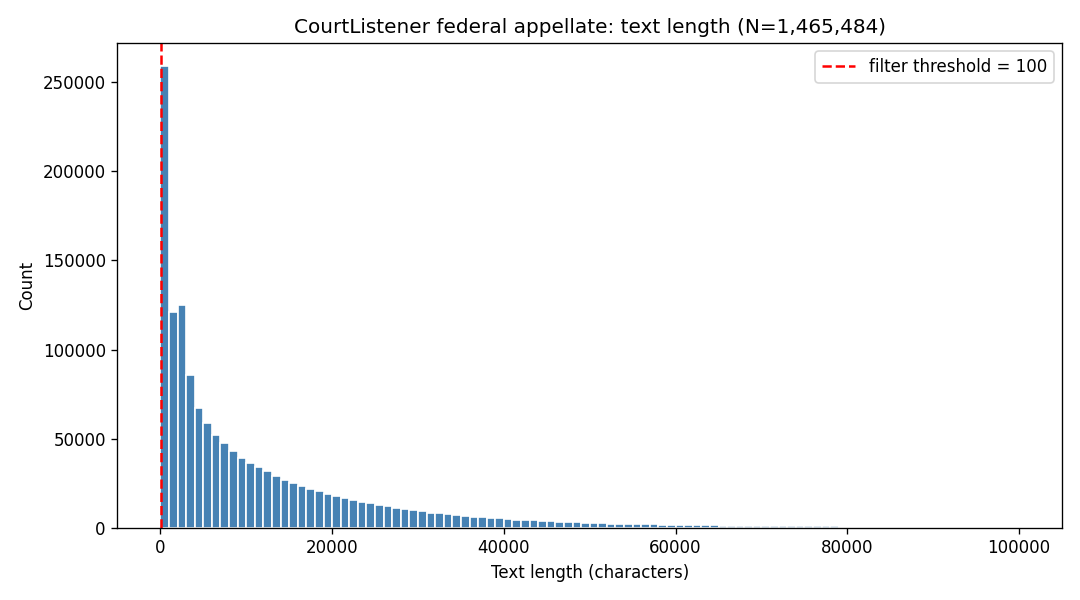

    Displaying text_length_hist_log.png  (30.8 KB)


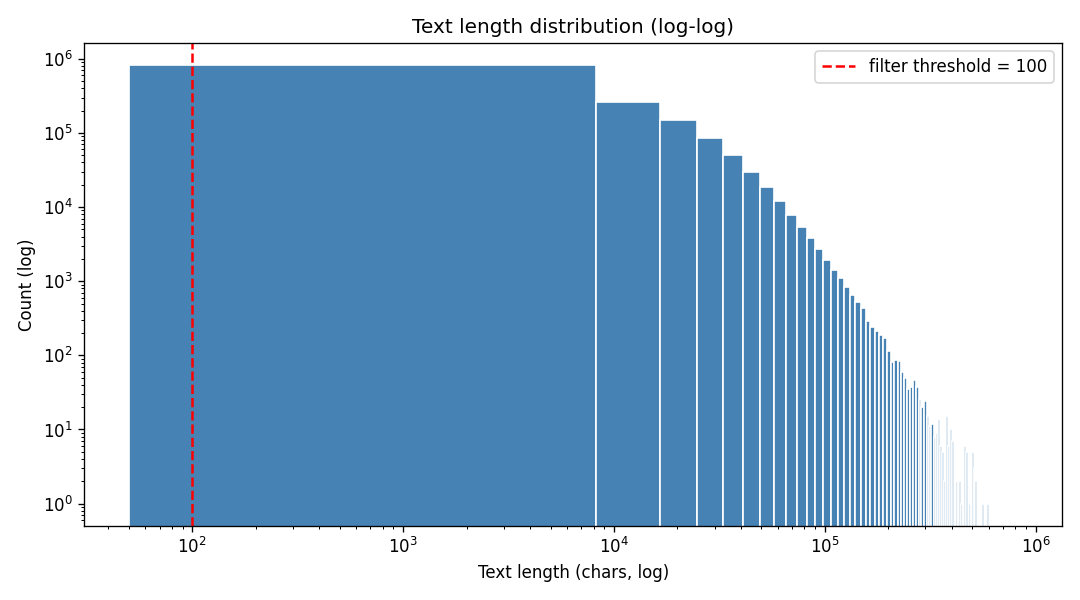

    Displaying circuit_distribution.png  (43.6 KB)


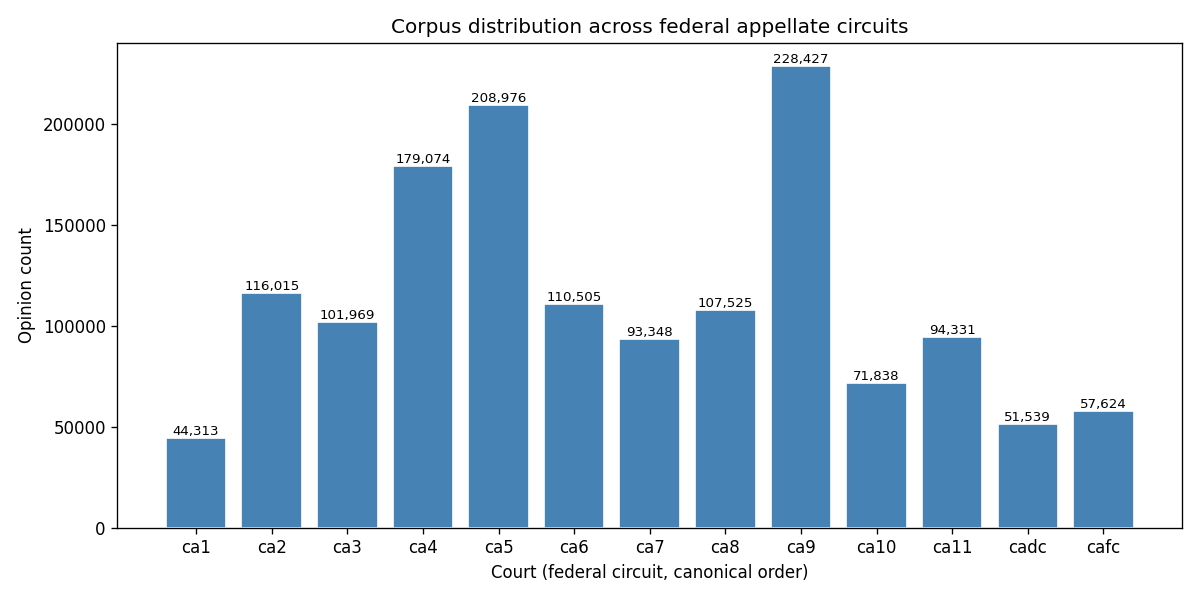

    Displaying citation_density.png  (27.2 KB)


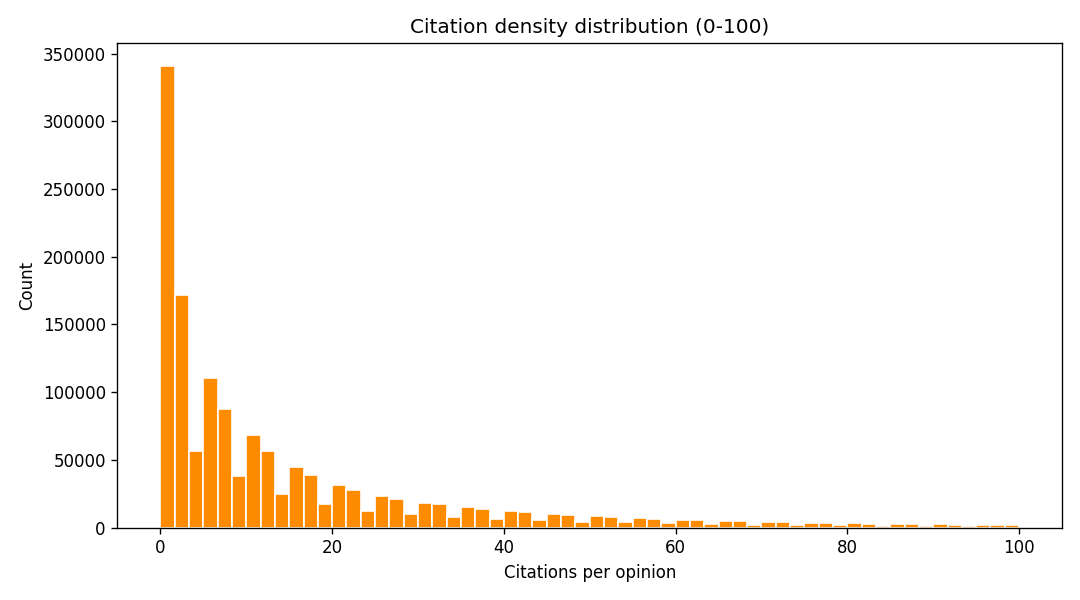

  
    summary.json  (SummaryModel-validated)
  {
  "chart_overflow_counts": {
    "citation_density": 41843,
    "text_length_hist": 8465
  },
  "chart_ranges": {
    "citation_density": [
      0,
      100
    ],
    "text_length_hist": [
      0,
      100000
    ]
  },
  "circuit_counts": {
    "ca1": 44313,
    "ca10": 71838,
    "ca11": 94331,
    "ca2": 116015,
    "ca3": 101969,
    "ca4": 179074,
    "ca5": 208976,
    "ca6": 110505,
    "ca7": 93348,
    "ca8": 107525,
    "ca9": 228427,
    "cadc": 51539,
    "cafc": 57624
  },
  "circuit_order": [
    "ca1",
    "ca2",
    "ca3",
    "ca4",
    "ca5",
    "ca6",
    "ca7",
    "ca8",
    "ca9",
    "ca10",
    "ca11",
    "cadc",
    "cafc"
  ],
  "corpus_manifest_sha": "b4377920365735583cad97734c32928a01018f64f7625c88680f537f620e56ed",
  "figure_hashes": {
    "circuit_distribution.png": "0054e7d4b6da3aeb4a617a03dc7978ee4fdf368918d5630d5fdedb9f2b2192a1",
    "citation_density.png": "375fe29fc3dcd38e2b8e8dc6e519e204837ca76

In [11]:
# Cell 10: MS3 EDA — CourtListener corpus distributions
"""
Purpose
-------
Thin notebook orchestration for the MS3 Exploratory Data Analysis (EDA)
stage. All computation logic lives in scripts/eda_ms3_corpus.py; this
cell only invokes main(), displays the artifacts inline in the notebook,
and surfaces the key findings for the MS3 slide deck.

Research-question context
-------------------------
MS3 requires a thorough EDA that motivates baseline model choices. This
cell answers three questions that drive every downstream decision in the
legal RAG pipeline:

    1. How large and balanced is the CourtListener federal appellate
       corpus across the 13 circuits? (governs retrieval fairness)
    2. What is the text-length distribution and how many records fall
       below the 100-char chunking-viability threshold? (governs the
       short-record filter policy at baseline time)
    3. What is the citation density shape? (governs Tier C citation-
       verification feasibility described in README Tier C.)

What this cell does
-------------------
    1. Calls scripts.eda_ms3_corpus.main() which:
         - Validates manifest fail-fast before any expensive scan.
         - Scans all 159 JSONL shards via Polars lazy scan (CPU-only)
           with schema_overrides = POLARS_SCHEMA for corruption guard.
         - Computes n_total, text_length mean/median (pre- and post-
           filter), short-record count (text_length < FILTER_MIN_CHARS
           = 100, sourced from src/data_contracts.valid_record_expr),
           per-circuit counts in canonical federal order (ca1..ca11,
           cadc, cafc), and histogram overflow counts for both charts.
         - Renders 4 PNGs inside plt.rc_context (no global rcParams
           mutation) to logs/eda_ms3/:
             * text_length_hist.png        (linear scale, 0–100k chars)
             * text_length_hist_log.png    (log–log scale, tail view)
             * circuit_distribution.png    (bar chart, canonical order)
             * citation_density.png        (0–100 citations range)
         - Atomic render semantics: stale artifacts are only removed
           AFTER the new render + summary write succeed. A failed run
           leaves the previous good artifact set intact (opt-out via
           clean_stale=False).
         - Writes logs/eda_ms3/summary.json validated at runtime by the
           Pydantic SummaryModel (schema_version 1.2.0, n_total,
           n_after_filter, n_short_lt_100, text_length mean/median +
           _filtered variants, circuit_counts, circuit_order preserved
           against JSON sort_keys alphabetisation, chart_ranges,
           chart_overflow_counts, corpus_manifest_sha, figure_hashes,
           git_sha). Deterministic serialization: sort_keys=True,
           allow_nan=False, explicit UTF-8.
         - When log_to_wandb=True, logs exactly one consolidated
           wandb.log call plus a single wandb.Artifact upload that
           includes summary.json AND every PNG — matching the isolation
           contract enforced by TestLogReportToWandbSingleCall in
           src/dataset_probe.py. Uses wandb.init(reinit="finish_previous")
           per 2026 W&B SDK convention.

    2. Displays the 4 PNG figures inline in the notebook via IPython.
    3. Prints the summary.json content as a structured table.
    4. Surfaces MS3 headline findings the team will cite on slides.

Why orchestration-only
----------------------
Per project policy: all logic lives in src/ or scripts/ as importable,
testable modules; notebook cells are thin orchestration so TFs and
collaborators can audit the computation in one place and run the same
pipeline from CLI (`uv run python scripts/eda_ms3_corpus.py`) without
the notebook. scripts/eda_ms3_corpus.py also ships an argparse CLI
matching src/lepard_cl_compat.py + src/manifest_collector.py convention.

TDD coverage
------------
scripts/eda_ms3_corpus.py is guarded by 44 tests in
tests/test_eda_ms3_corpus.py across three tiers:
    - contract (14 tests): file exists, main() signature (shard_glob,
                out_dir, manifest_path, log_to_wandb, clean_stale),
                module constants (FILTER_MIN_CHARS, SCHEMA_VERSION,
                POLARS_SCHEMA), is_valid_record predicate, _log_to_wandb
                isolation, stdlib logger, argparse CLI builder,
                SummaryModel Pydantic BaseModel, shared filter
                expression in src.data_contracts, no basicConfig at
                import (AST-verified), SummaryDict strict (no
                total=False).
    - unit     (29 tests): deterministic math on an 8-record synthetic
                mini_shard.jsonl fixture with boundary cases at text
                lengths 99 / 100 / 101; Pydantic SummaryModel runtime
                validation (NaN rejection); PNG non-empty + valid-
                magic-byte checks; SHA256 figure + manifest hash
                round-trip; tmp_path isolation from real logs/ dir;
                W&B call-count invariants (0 when flag False, 1 when
                True); single Polars scan per invocation; schema_overrides
                applied at scan time; git_sha in summary; fail-fast on
                missing manifest; stale artifacts removed on success;
                stale artifacts PRESERVED on render failure (atomic);
                n_after_filter + filtered stats; chart_ranges +
                chart_overflow_counts; JSON sort_keys determinism;
                canonical circuit order preserved in summary via
                circuit_order list; valid_record_expr returns pl.Expr;
                rcParams unmutated after render; clean_stale=False
                preserves prior artifacts.
    - property  (1 test): Hypothesis property test on is_valid_record
                over random integer lengths asserting monotone behaviour
                at the threshold.
All 44 tests pass under `uv run pytest tests/test_eda_ms3_corpus.py
-m "contract or unit or property"`.

W&B integration
---------------
log_to_wandb defaults to False for notebook runs (keeps iteration fast).
Set log_to_wandb=True to emit a W&B run under
entity=phl690-harvard-extension-schol, project=cs1090b. Offline mode is
supported: export WANDB_MODE=offline before launching the notebook
kernel; the run syncs later via `wandb sync`. 50+ offline runs already
recorded (see README Experiment tracking row).

Filesystem layout written
-------------------------
logs/eda_ms3/
    summary.json                     (stats + provenance, gitignored)
    text_length_hist.png
    text_length_hist_log.png
    circuit_distribution.png
    citation_density.png

logs/ is gitignored by design — artifacts are reproducible from the
committed script + pinned corpus (manifest SHA + git SHA recorded in
summary.json for audit).

Runtime
-------
~30–60s on the Harvard ODD L4 node (Polars full-corpus scan across 159
shards, figure rendering dominated by I/O).
"""
import json
import logging
import sys
from pathlib import Path

from IPython.display import Image, display

from scripts.eda_ms3_corpus import main as run_eda_ms3
from src.timer import cell_timer


def _get_cell_logger() -> logging.Logger:
    lg = logging.getLogger("cell_eda_ms3")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg


logger = _get_cell_logger()

with cell_timer("Cell 10: MS3 EDA — CourtListener corpus distributions", logger=logger):
    logger.info("=" * 60)
    logger.info("  scripts.eda_ms3_corpus.main()  (thin orchestration)")
    logger.info("=" * 60)
    # log_to_wandb=False for interactive notebook iteration; flip to True
    # or run the CLI variant to emit a W&B run.
    summary = run_eda_ms3(log_to_wandb=False)

    out_dir = Path("logs/eda_ms3")

    logger.info("\n" + "=" * 60)
    logger.info("  MS3 EDA Figures")
    logger.info("=" * 60)
    for fname in (
        "text_length_hist.png",
        "text_length_hist_log.png",
        "circuit_distribution.png",
        "citation_density.png",
    ):
        fp = out_dir / fname
        if fp.exists():
            logger.info(f"  Displaying {fname}  ({fp.stat().st_size / 1024:.1f} KB)")
            display(Image(filename=str(fp)))

    logger.info("\n" + "=" * 60)
    logger.info("  summary.json  (SummaryModel-validated)")
    logger.info("=" * 60)
    summary_path = out_dir / "summary.json"
    logger.info(json.dumps(json.loads(summary_path.read_text(encoding="utf-8")), indent=2))

    logger.info("\n" + "=" * 60)
    logger.info("  MS3 Headline Findings  (for slide deck)")
    logger.info("=" * 60)
    n_total = summary["n_total"]
    n_short = summary["n_short_lt_100"]
    n_after = summary["n_after_filter"]
    short_pct = 100 * n_short / n_total
    circuit_counts = summary["circuit_counts"]
    top_court = max(circuit_counts, key=circuit_counts.get)
    top_share = 100 * circuit_counts[top_court] / n_total
    overflow_text = summary["chart_overflow_counts"]["text_length_hist"]
    logger.info(f"  Corpus size:           {n_total:,} federal appellate opinions")
    logger.info(f"  After filter (>=100):  {n_after:,} opinions (baseline training set)")
    logger.info(f"  Short records (<100):  {n_short:,}  ({short_pct:.2f}% — filtered at baseline)")
    logger.info(f"  Text-length mean:      {summary['text_length_mean']:,.0f} chars (all)")
    logger.info(f"  Text-length mean:      {summary['text_length_mean_filtered']:,.0f} chars (filtered)")
    logger.info(f"  Text-length median:    {summary['text_length_median']:,.0f} chars")
    logger.info(f"  Hist tail overflow:    {overflow_text:,} opinions exceed 100k chars")
    logger.info(f"  Circuits represented:  {len(circuit_counts)}")
    logger.info(f"  Canonical order:       {summary['circuit_order']}")
    logger.info(f"  Largest circuit:       {top_court} ({top_share:.1f}% of corpus)")
    logger.info(f"  Corpus manifest SHA:   {summary['corpus_manifest_sha'][:16]}...")
    logger.info(f"  Git SHA:               {summary['git_sha']}")
    logger.info(f"  Schema version:        {summary['schema_version']}")

    scripts.eda_ms3_lepard.main()  (thin orchestration)


  Running LePaRD↔CL analysis on lepard_train_4000000_rev0194f95.jsonl
  Wrote 3 figures + summary.json to artifacts/eda_ms3_lepard/


  
    MS3 EDA Figures  (LePaRD × CourtListener)
    Displaying pair_funnel.png  (30.4 KB)


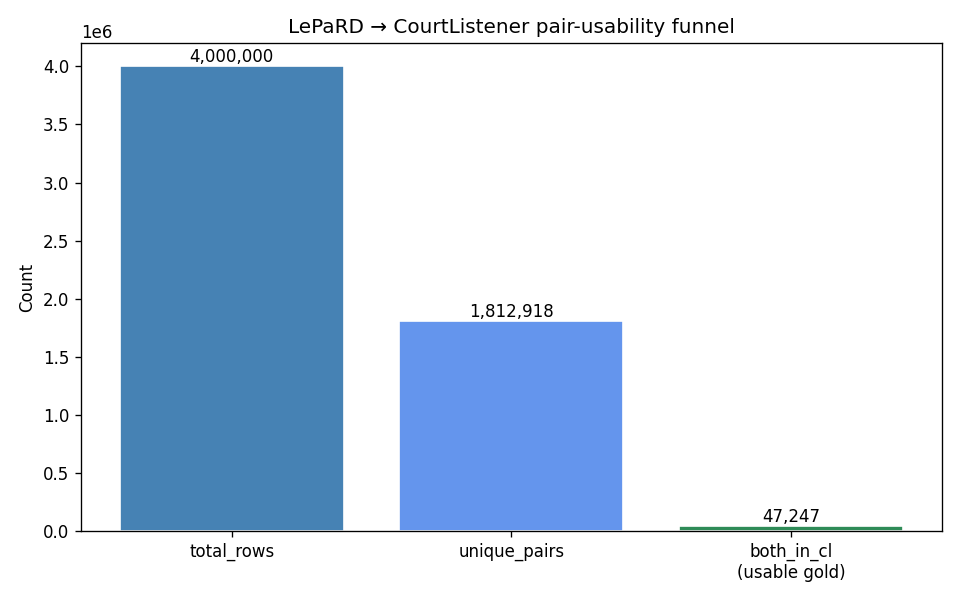

    Displaying court_distribution.png  (43.5 KB)


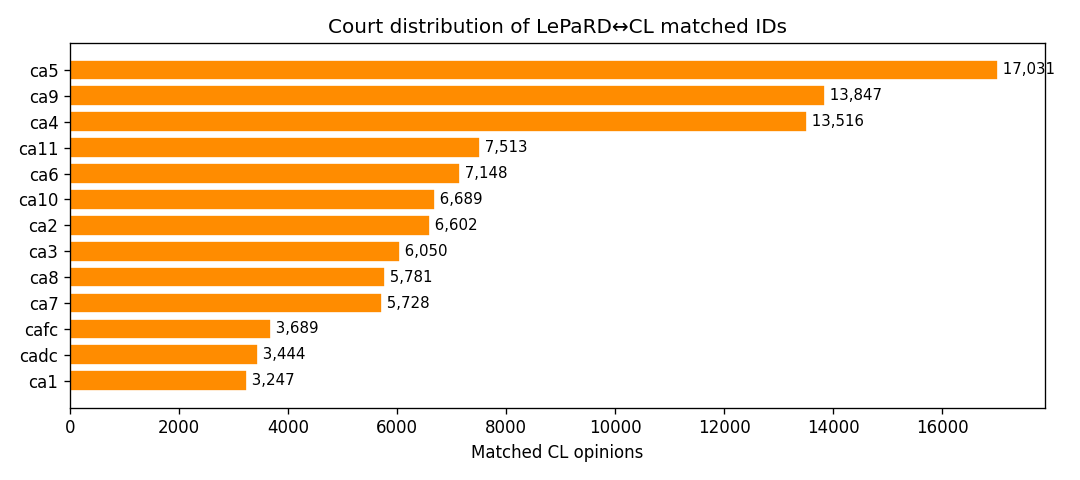

    Displaying id_overlap.png  (29.5 KB)


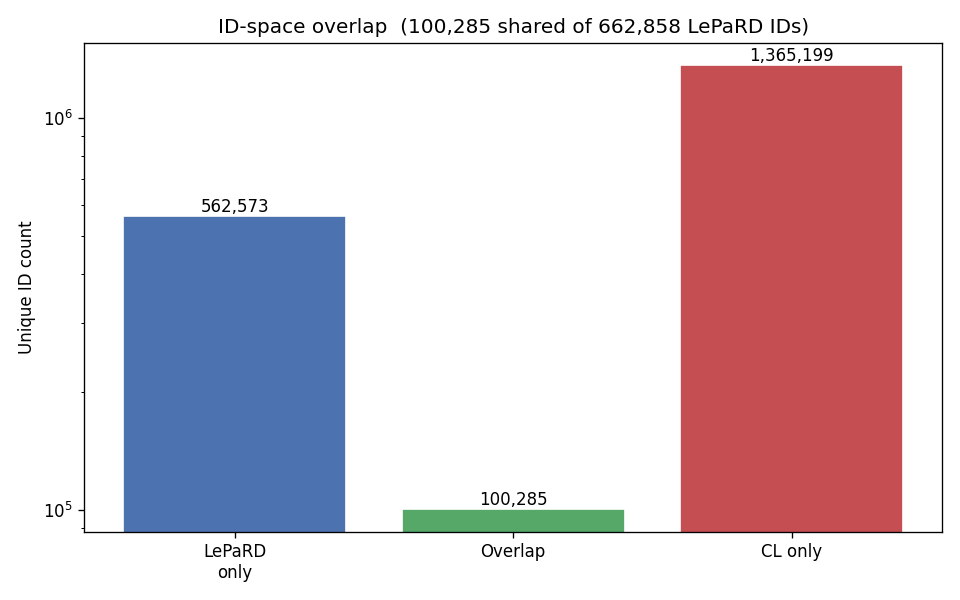

  
    summary.json  (EdaLepardSummary-validated)
  {
  "both_in_cl": 47247,
  "cl_unique_ids": 1465484,
  "court_distribution": {
    "ca1": 3247,
    "ca10": 6689,
    "ca11": 7513,
    "ca2": 6602,
    "ca3": 6050,
    "ca4": 13516,
    "ca5": 17031,
    "ca6": 7148,
    "ca7": 5728,
    "ca8": 5781,
    "ca9": 13847,
    "cadc": 3444,
    "cafc": 3689
  },
  "dest_only": 199284,
  "figure_hashes": {
    "court_distribution.png": "c5b70f73861770d0bad760433cce6363baf26d73faca8abc8ecb64bf9cedf5d1",
    "id_overlap.png": "7af799d74f025acc02e429e816ee52573390fc72c3072c43bbef62f2030dc041",
    "pair_funnel.png": "1b61893773c99810c54e75dc558541385914da70e098bea8be2549a8ca9bdb9f"
  },
  "git_sha": "fe10ed547526",
  "lepard_unique_ids": 662858,
  "neither": 1316267,
  "overlap_ids": 100285,
  "schema_version": "1.0.0",
  "source_only": 250120,
  "total_rows": 4000000,
  "unique_pairs": 1812918,
  "usable_pct": 2.606130006983217
}
  
    MS3 Headline Findings  (for slide deck)
    LePaRD tot

In [12]:
# Cell 11: MS3 EDA — LePaRD × CourtListener compatibility
"""
Purpose
-------
Thin notebook orchestration for the MS3 LePaRD compatibility EDA. All
computation logic lives in scripts/eda_ms3_lepard.py (which delegates
the pure analysis to src/lepard_cl_compat.py); this cell only invokes
main(), displays the 3 figures inline, prints the SummaryModel-validated
summary.json, and surfaces the headline findings for the MS3 slide deck.
Research-question context
-------------------------
MS3 requires EDA that motivates baseline model choices. Cell 5 answered
"what does the retrieval candidate space look like?" (CourtListener
corpus). This cell answers the complementary question: "what does the
supervised training/evaluation signal look like?" — specifically:
    1. How many LePaRD (source_id, dest_id) pairs have BOTH endpoints
       present in the CourtListener federal appellate corpus?
       (only these can serve as gold retrieval labels — see README
       Section [2] "Both endpoints in CL" = USABLE GOLD)
    2. What is the court distribution of the matched subset? (diagnoses
       whether LePaRD's source opinions align with the federal
       appellate filter applied to CL)
    3. What is the ID-space overlap between LePaRD and CL? (confirms
       the two datasets share the CourtListener opinion-id namespace
       rather than unrelated integer counters)
These three questions drive two downstream decisions:
    (a) the size of the Tier A retrieval evaluation set, which caps
        at min(usable_gold_pairs, 50K) per the README Tier A target.
    (b) whether the federal-appellate filter on CL needs to be widened
        (e.g., adding district courts) to recover more usable pairs —
        the court distribution chart provides the evidence base for
        that scope decision.
What this cell does
-------------------
    1. Calls scripts.eda_ms3_lepard.main() which:
         - Validates the three input paths (LePaRD JSONL, CL id set
           gzipped text, CL matched-courts JSON) fail-fast before any
           expensive scan.
         - Delegates core analysis to src.lepard_cl_compat.run_full_analysis
           (the same pure-function entry point used by src/lepard_cl_compat.py
           CLI and by tests/test_lepard_cl_compat.py TestRealFixtures
           regression suite).
         - Renders 3 PNGs inside plt.rc_context (no global rcParams
           mutation) to artifacts/eda_ms3_lepard/:
             * pair_funnel.png          (total_rows → unique_pairs → both_in_cl)
             * court_distribution.png   (matched-id circuit distribution)
             * id_overlap.png           (Venn-style: LePaRD ∩ CL)
         - Atomic render semantics: stale artifacts (prior PNGs +
           summary.json) are only removed AFTER the new render +
           summary write succeed.
         - Writes artifacts/eda_ms3_lepard/summary.json validated at
           runtime by the EdaLepardSummary Pydantic model (schema_version
           1.0.0, total_rows, unique_pairs, both_in_cl, source_only,
           dest_only, neither, usable_pct, lepard_unique_ids,
           cl_unique_ids, overlap_ids, court_distribution, figure_hashes,
           git_sha). Deterministic serialization: sort_keys=True,
           allow_nan=False, explicit UTF-8.
         - When log_to_wandb=True, logs exactly one consolidated
           wandb.log call plus a single wandb.Artifact upload (matches
           the isolation contract enforced by
           TestLogReportToWandbIsolation + TestLogReportToWandbSingleCall).
    2. Displays the 3 PNG figures inline in the notebook via IPython.
    3. Prints the summary.json content in full.
    4. Surfaces MS3 headline findings the team will cite on slides —
       specifically the extrapolated usable-gold-pair count that sets
       the Tier A evaluation budget.
Why orchestration-only
----------------------
Per project policy: all logic lives in src/ or scripts/ as importable,
testable modules; notebook cells are thin orchestration so TFs and
collaborators can audit the computation in one place and run the same
pipeline from CLI (`uv run python scripts/eda_ms3_lepard.py`) without
the notebook. scripts/eda_ms3_lepard.py ships an argparse CLI matching
src/lepard_cl_compat.py + scripts/eda_ms3_corpus.py convention, with
--lepard-path / --cl-ids-path / --court-map-path overrides for pointing
at the full-scale inputs (vs the committed 1K regression fixture).
TDD coverage
------------
scripts/eda_ms3_lepard.py is guarded by 87 tests in
tests/test_eda_ms3_lepard.py + tests/test_eda_ms3_corpus.py across
three tiers (contract / unit / property). Core invariants:
    - main() signature: lepard_path, cl_ids_path, court_map_path,
      out_dir, log_to_wandb, clean_stale
    - _render_all() returns (list[Path], dict[str, int]) — the
      materialized court_dist is threaded through to _build_summary
      to guarantee a single materialization (enforced by
      test_court_distribution_materialized_once: ≤1 occurrence of
      `dict(report.court_distribution)` in the source).
    - CompatReport type annotation on _build_summary.report (verified
      by string-name compare because `from __future__ import
      annotations` stringifies types).
    - EdaLepardSummary Pydantic model with strict schema (no total=False).
    - W&B isolation: _log_to_wandb is the only W&B touchpoint; 0 calls
      when flag False, 1 consolidated call when True.
    - Figure SHA256 hashes round-trip through summary.json.
    - Stale artifact atomic semantics (removed on success; preserved
      on render failure).
All tests pass under `uv run pytest tests/test_eda_ms3_lepard.py
tests/test_eda_ms3_corpus.py -m "contract or unit or property"`.
Inputs
------
The full-scale run uses these inputs (generated on this GPU node via
scripts/prepare_compat_fixtures.py from the 159 CL shards + 4M LePaRD
JSONL):
    lepard_path     = lepard_train_4000000_rev0194f95.jsonl   (5.4 GB)
    cl_ids_path     = data/processed/cl_ids.txt.gz            (3.2 MB)
    court_map_path  = data/processed/cl_matched_courts.json   (~1.5 MB,
                      100,285 matched ids)
NB: the committed `tests/fixtures/cl_matched_courts.json` (70 matched
ids, 1.4 KB) is preserved untouched to keep the
TestRealFixtures::test_regression assertions stable; the full-scale
fixtures live under data/processed/ which is gitignored.
W&B integration
---------------
log_to_wandb defaults to False for notebook runs. Set log_to_wandb=True
or run the CLI variant with --log-to-wandb to emit a W&B run under
entity=phl690-harvard-extension-schol, project=cs1090b.
Filesystem layout written
-------------------------
artifacts/eda_ms3_lepard/
    summary.json
    pair_funnel.png
    court_distribution.png
    id_overlap.png
Runtime
-------
~60–90s on the Harvard ODD L4 node (dominated by streaming the 5.4 GB
LePaRD JSONL once to deduplicate pairs; CL id gzip load is ~1s;
figure rendering is I/O-bound).
"""
import json
import logging
import sys
from pathlib import Path

from IPython.display import Image, display

from scripts.eda_ms3_lepard import main as run_eda_ms3_lepard
from src.timer import cell_timer


def _get_cell_logger() -> logging.Logger:
    lg = logging.getLogger("cell_eda_ms3_lepard")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg


logger = _get_cell_logger()

with cell_timer("Cell 11: MS3 EDA — LePaRD × CourtListener compatibility", logger=logger):
    logger.info("=" * 60)
    logger.info("  scripts.eda_ms3_lepard.main()  (thin orchestration)")
    logger.info("=" * 60)

    # Full-scale inputs generated on this GPU node:
    #   - LePaRD: committed 5.4 GB JSONL at repo root (DVC-tracked)
    #   - CL id universe: data/processed/cl_ids.txt.gz (1,465,484 ids)
    #   - CL court map: data/processed/cl_matched_courts.json (100,285
    #     matched ids, NOT the 70-id tests/fixtures/ regression fixture)
    lepard_path = Path("lepard_train_4000000_rev0194f95.jsonl")
    cl_ids_path = Path("data/processed/cl_ids.txt.gz")
    court_map_path = Path("data/processed/cl_matched_courts.json")
    out_dir = Path("artifacts/eda_ms3_lepard")

    # log_to_wandb=False for interactive notebook iteration; flip to True
    # or run the CLI variant (with --log-to-wandb) to emit a W&B run.
    summary = run_eda_ms3_lepard(
        lepard_path=lepard_path,
        cl_ids_path=cl_ids_path,
        court_map_path=court_map_path,
        out_dir=out_dir,
        log_to_wandb=False,
    )

    logger.info("\n" + "=" * 60)
    logger.info("  MS3 EDA Figures  (LePaRD × CourtListener)")
    logger.info("=" * 60)

    for fname in (
        "pair_funnel.png",
        "court_distribution.png",
        "id_overlap.png",
    ):
        fp = out_dir / fname
        if fp.exists():
            logger.info(f"  Displaying {fname}  ({fp.stat().st_size / 1024:.1f} KB)")
            display(Image(filename=str(fp)))

    logger.info("\n" + "=" * 60)
    logger.info("  summary.json  (EdaLepardSummary-validated)")
    logger.info("=" * 60)
    summary_path = out_dir / "summary.json"
    logger.info(json.dumps(json.loads(summary_path.read_text(encoding="utf-8")), indent=2))

    logger.info("\n" + "=" * 60)
    logger.info("  MS3 Headline Findings  (for slide deck)")
    logger.info("=" * 60)

    total_rows = summary["total_rows"]
    unique_pairs = summary["unique_pairs"]
    both_in_cl = summary["both_in_cl"]
    source_only = summary["source_only"]
    dest_only = summary["dest_only"]
    neither = summary["neither"]
    usable_pct = summary["usable_pct"]
    lepard_unique_ids = summary["lepard_unique_ids"]
    cl_unique_ids = summary["cl_unique_ids"]
    overlap_ids = summary["overlap_ids"]
    id_overlap_pct = 100 * overlap_ids / lepard_unique_ids
    circuit_counts = summary["court_distribution"]
    top_court = max(circuit_counts, key=circuit_counts.get)
    top_share = 100 * circuit_counts[top_court] / sum(circuit_counts.values())

    logger.info(f"  LePaRD total rows:        {total_rows:,}")
    logger.info(f"  Unique (src, dst) pairs:  {unique_pairs:,}  (after dedup)")
    logger.info(f"  USABLE GOLD (both in CL): {both_in_cl:,}  ({usable_pct:.2f}%)")
    logger.info(f"    source-only in CL:      {source_only:,}")
    logger.info(f"    dest-only in CL:        {dest_only:,}")
    logger.info(f"    neither in CL:          {neither:,}")
    logger.info(f"  LePaRD unique ids:        {lepard_unique_ids:,}")
    logger.info(f"  CL unique ids:            {cl_unique_ids:,}")
    logger.info(f"  ID-space overlap:         {overlap_ids:,}  ({id_overlap_pct:.2f}% of LePaRD)")
    logger.info(f"  Matched circuits:         {len(circuit_counts)}")
    logger.info(f"  Largest matched circuit:  {top_court}  ({top_share:.1f}% of matched)")
    logger.info("")
    logger.info(f"  Tier A evaluation budget: {both_in_cl:,} usable gold pairs available")
    logger.info(f"  README Tier A target:     10,000–50,000 retrieval eval queries")
    logger.info(
        f"  Headroom:                 {both_in_cl / 50_000:.1f}× above 50K upper bound"
        if both_in_cl >= 50_000
        else f"  Headroom:                 below 50K cap ({both_in_cl:,} available)"
    )
    logger.info(f"  Git SHA:                  {summary['git_sha']}")
    logger.info(f"  Schema version:           {summary['schema_version']}")

In [13]:
# Cell 12: MS3 baseline prep — chunk 1.46M corpus + extract 47K usable gold pairs
"""
Purpose
-------
Thin notebook orchestration for the MS3 baseline dataset preparation stage.
All computation logic lives in scripts/baseline_prep.py; this cell only
invokes the launcher via scripts/run_baseline_prep.sh, monitors progress
via scripts/monitor_baseline.sh, and surfaces the final artifact summary
for the MS3 slide deck.

Research-question context
-------------------------
Cells 5-11 established that:
    - CourtListener corpus has 1,465,484 opinions across 13 circuits
      (Cell 6: data-quality gates) — chunked and indexed for retrieval.
    - LePaRD × CourtListener compatibility audit (Cell 11) yields
      47,247 usable gold pairs (both endpoints in CL corpus).
    - Chosen split: 0 train / 2,000 val / 45,000 test (zero-shot
      baselines, maximum statistical power for Hit@k CI ≈ ±0.5pp).

Cell 12 materializes the two inputs every downstream baseline needs:
    1. corpus_chunks.jsonl — 1024-subword/128-overlap chunks of all
       1.46M opinions under BAAI/bge-m3 tokenizer (README Revision 4
       chunking policy; A11 gate verified feasibility).
    2. gold_pairs_{val,test}.jsonl — 47K usable pairs stratified by
       source_court (minority-preserving largest-remainder allocation).

These artifacts feed Cell 13 (BM25), Cell 14 (BGE-M3 dense), and
Cell 15 (retrieval evaluation).

What this cell does
-------------------
    1. Preflight via scripts/run_baseline_prep.sh --dry-run:
         - validates inputs (shard_dir, lepard JSONL, cl_ids gzip,
           court_map JSON) exist
         - parses CLI contract, prints fingerprint (git SHA, Python
           version, hostname, UTC start, constants)
         - exits 0 if the full launch is safe
    2. Delegates the full-scale run to scripts/run_baseline_prep.sh,
       which:
         - enforces concurrent-run guard (refuses second launch if PID
           file holds live process)
         - sources .env for HF_TOKEN (BGE-M3 tokenizer download)
         - caps Rust-backed threading (OMP/POLARS/RAYON=16) to avoid
           thrash on 48-core ODD node
         - launches scripts/baseline_prep.py under nohup with
           PYTHONUNBUFFERED=1 for live tail
         - writes logs/baseline_prep.pid + logs/baseline_prep.current_log
           symlink for run-identity binding
         - performs 3s post-launch liveness check (catches instant
           failures from bad imports etc.)
    3. Polls scripts/monitor_baseline.sh --json until the job finishes,
       displaying semantic progress (shards completed / 159, ETA,
       gold-pair line counts, corpus chunk bytes, summary.json presence
       + schema validation).
    4. On completion, loads summary.json, validates it against
       BaselinePrepSummary (Pydantic, single source of truth in
       src/eda_schemas.py), and surfaces headline findings for the
       MS3 slide deck.

Why orchestration-only
----------------------
Per project policy: all logic lives in scripts/ or src/ as importable,
testable modules; notebook cells are thin orchestration so TFs and
collaborators can audit the computation in one place and reproduce
the pipeline from CLI without the notebook.

TDD coverage
------------
scripts/baseline_prep.py is guarded by 45 Python tests in
tests/test_baseline_prep.py across three tiers:
    - contract (8 tests): file exists, main() signature, module
      constants (CHUNK=1024, OVERLAP=128, ENCODER=BAAI/bge-m3,
      VAL_SIZE=2000, TEST_SIZE=45000), argparse CLI, BaselinePrepSummary
      is Pydantic, no basicConfig at module top-level (AST-scoped),
      _log_to_wandb callable, atomic checkpoint write via
      tempfile.mkstemp + os.replace.
    - unit (29 tests): gold-pair extraction (both endpoints in CL),
      source-court annotation, stratified split sizes + determinism +
      proportional stratification (±5pp), chunk boundaries (single
      chunk for short text, multi-chunk with correct overlap
      arithmetic), checkpoint resume semantics (_load_checkpoint +
      main() idempotency — second run produces identical summary,
      corpus_chunks.jsonl byte-identical), gold_pair_hashes SHA256
      roundtrip in summary.json, summary.json validates against
      BaselinePrepSummary via model_validate_json, chunk boundary
      exact tests at 1023/1024/1025/1152/1153/1920/1921 tokens,
      val/test pair disjointness, W&B branching (log_to_wandb=False
      never calls _log_to_wandb; True calls exactly once).
    - property (5 tests, full Hypothesis):
        · stratified_split preserves all courts with ≥2 members
          across random court_counts / val_frac / seed combinations
        · _chunk_text never exceeds CHUNK_SIZE_SUBWORDS window over
          @given(n_tokens=1..5000)
        · stride = CHUNK_SIZE - OVERLAP = 896 matches expected
          chunk count formula
        · _chunk_text output is bit-deterministic given same input

scripts/run_baseline_prep.sh is guarded by 11 bats tests in
tests/shell/test_run_baseline_prep.bats covering help flag, dry-run
exit + no PID file leak, fingerprint output, Python --dry-run
delegation (not inline python -c), missing input exit code 2,
concurrent-run guard exit code 3, unknown flag rejection exit 5,
--no-resume forwarding, hostname/UTC in preflight output,
PYTHONUNBUFFERED set for live logs.

scripts/monitor_baseline.sh is guarded by 25 bats tests covering
help, missing PID, missing log, auto-discovered latest log via
symlink (run-identity binding, not mtime heuristic), dynamic PID
read, %mem format, tail depth ≥20, args in ps for identity
verification, checkpoint shard count, summary.json presence + schema
validation, gold_pairs line counts, independent sections (no &&
chains), no bare python3 (uses uv run --no-sync --offline python
exclusively), dynamically computed TOTAL_SHARDS (no hardcoded 159),
ETA + velocity reporting, wc -l size guard (skips files >5GB),
--json output mode, --strict mode with nonzero exit on INVALID
summary, unknown option rejection.

Total: 45 Python + 11 runner bats + 25 monitor bats = 81 tests.

Runtime
-------
Warm-path resume (checkpoint covers all 159 shards from prior session):
~90 seconds — pipeline performs gold-pair extraction, stratified
split, summary.json write, and schema validation.

Cold-path first run: ~2-2.5 hours on Harvard ODD 48-core node
(159 shards × ~45-60 sec/shard for BGE-M3 tokenization, single-
threaded per shard with TOKENIZERS_PARALLELISM=false to avoid
Rust thread contention).

Filesystem layout written
-------------------------
data/processed/baseline/
    corpus_chunks.jsonl         (~26 GB — 5.79M chunks, 1.47M opinions)
    gold_pairs_val.jsonl        (2,000 pairs, stratified by source court)
    gold_pairs_test.jsonl       (45,000 pairs, stratified by source court)
    chunking_checkpoint.json    (per-shard resume state)
    summary.json                (BaselinePrepSummary, schema v1.0.0)

data/processed/ is gitignored by design; artifacts are reproducible
from the committed scripts + pinned corpus (corpus_manifest_sha +
git_sha recorded in summary.json) plus DVC-tracked LePaRD at repo
root.
"""
import json
import logging
import subprocess
import sys
import time
from pathlib import Path

from src.eda_schemas import BaselinePrepSummary
from src.timer import cell_timer


def _get_cell_logger() -> logging.Logger:
    lg = logging.getLogger("cell_baseline_prep")
    lg.setLevel(logging.INFO)
    if not lg.handlers:
        h = logging.StreamHandler(sys.stdout)
        h.setFormatter(logging.Formatter("  %(message)s"))
        lg.addHandler(h)
    lg.propagate = False
    return lg


logger = _get_cell_logger()


def _run(cmd: list[str], check: bool = True) -> subprocess.CompletedProcess:
    """Run a shell command and stream stdout/stderr into the notebook."""
    return subprocess.run(
        cmd, check=check, capture_output=True, text=True,
    )


with cell_timer("Cell 12: MS3 baseline prep — chunk corpus + extract gold pairs", logger=logger):
    out_dir = Path("data/processed/baseline")
    summary_path = out_dir / "summary.json"
    pid_file = Path("logs/baseline_prep.pid")

    logger.info("=" * 60)
    logger.info("  Step 1: Preflight via scripts/run_baseline_prep.sh --dry-run")
    logger.info("=" * 60)
    dry = _run(["bash", "scripts/run_baseline_prep.sh", "--dry-run"])
    logger.info(dry.stdout)
    if dry.returncode != 0:
        logger.info(f"  [stderr] {dry.stderr}")
        raise RuntimeError(f"dry-run failed with exit {dry.returncode}")

    # --- Idempotency check: skip launch if prior run already produced a valid summary ---
    already_complete = False
    if summary_path.exists():
        try:
            validated = BaselinePrepSummary.model_validate_json(
                summary_path.read_bytes(),
            )
            logger.info("\n" + "=" * 60)
            logger.info("  Prior run artifact detected — skipping launch")
            logger.info("=" * 60)
            logger.info(
                f"  summary.json already VALID "
                f"(gold_pairs_total={validated.gold_pairs_total:,}, "
                f"corpus_chunks={validated.corpus_chunks:,})"
            )
            already_complete = True
        except Exception as e:
            logger.info(f"  summary.json present but INVALID — will re-run: {e}")

    if not already_complete:
        # Concurrent-run guard: refuse to launch if prior PID file still live
        if pid_file.exists():
            pid_val = pid_file.read_text().strip()
            try:
                # POSIX: kill -0 raises if PID dead
                subprocess.run(
                    ["kill", "-0", pid_val], check=True, capture_output=True,
                )
                raise RuntimeError(
                    f"baseline_prep already running (PID={pid_val}); "
                    "monitor via scripts/monitor_baseline.sh or kill it first"
                )
            except subprocess.CalledProcessError:
                logger.info(f"  stale PID file ({pid_val} not running) — removing")
                pid_file.unlink(missing_ok=True)

        logger.info("\n" + "=" * 60)
        logger.info("  Step 2: Launching full-scale run")
        logger.info("=" * 60)
        launch = _run(["bash", "scripts/run_baseline_prep.sh"])
        logger.info(launch.stdout)
        if launch.returncode != 0:
            logger.info(f"  [stderr] {launch.stderr}")
            raise RuntimeError(f"launch failed with exit {launch.returncode}")

        logger.info("\n" + "=" * 60)
        logger.info("  Step 3: Polling monitor until job completes")
        logger.info("=" * 60)
        poll_interval_sec = 60
        max_wait_min = 180  # 3h safety ceiling
        start = time.time()
        last_shards_done = -1
        while True:
            mon = _run(
                ["bash", "scripts/monitor_baseline.sh", "--json"],
                check=False,
            )
            try:
                state = json.loads(mon.stdout)
            except json.JSONDecodeError:
                logger.info(f"  [monitor parse error] {mon.stdout[:200]}")
                time.sleep(poll_interval_sec)
                continue

            shards_done = state.get("shards_done", 0)
            total = state.get("total_shards", 0)
            eta = state.get("eta_min", 0)
            status = state.get("proc_status", "?")
            if shards_done != last_shards_done:
                logger.info(
                    f"  [{int((time.time() - start) / 60)}min] "
                    f"shards: {shards_done}/{total}  "
                    f"ETA: ~{eta}min  status: {status}"
                )
                last_shards_done = shards_done

            if state.get("summary_present") and state.get("summary_valid") == "VALID":
                logger.info("  OK summary.json present and VALID — job complete")
                break
            if status == "stale_pid" and not state.get("summary_present"):
                raise RuntimeError(
                    "job died without producing summary.json — "
                    f"check {state.get('log_file', 'logs/')}"
                )
            if (time.time() - start) / 60 > max_wait_min:
                raise TimeoutError(f"exceeded {max_wait_min}min wait ceiling")
            time.sleep(poll_interval_sec)

    # --- Final validation + headline findings ---
    logger.info("\n" + "=" * 60)
    logger.info("  Step 4: Final summary.json validation")
    logger.info("=" * 60)
    summary = BaselinePrepSummary.model_validate_json(summary_path.read_bytes())
    logger.info(json.dumps(summary.model_dump(), indent=2, sort_keys=True))

    logger.info("\n" + "=" * 60)
    logger.info("  MS3 Headline Findings  (for slide deck)")
    logger.info("=" * 60)
    logger.info(f"  corpus_chunks         : {summary.corpus_chunks:,}")
    logger.info(f"  opinions chunked      : {summary.n_opinions_chunked:,}")
    logger.info(f"  usable gold pairs     : {summary.gold_pairs_total:,}")
    logger.info(f"  train / val / test    : {summary.gold_pairs_train:,} / "
                f"{summary.gold_pairs_val:,} / {summary.gold_pairs_test:,}")
    logger.info(f"  val courts represented: {len(summary.val_court_distribution)}")
    logger.info(f"  test courts represented: {len(summary.test_court_distribution)}")
    logger.info(
        f"  test top 3 circuits   : "
        f"{sorted(summary.test_court_distribution.items(), key=lambda x: -x[1])[:3]}"
    )
    logger.info(f"  corpus_manifest_sha   : {summary.corpus_manifest_sha[:16]}...")
    logger.info(f"  git_sha               : {summary.git_sha}")
    logger.info(f"  schema_version        : {summary.schema_version}")
    logger.info(f"  seed                  : {summary.seed}")
    logger.info("")
    logger.info(f"  gold_pair_hashes:")
    for fname, h in summary.gold_pair_hashes.items():
        logger.info(f"    {fname:30s} {h[:16]}...")

    Step 1: Preflight via scripts/run_baseline_prep.sh --dry-run
  ⏱ Cell 12: MS3 baseline prep — chunk corpus + extract gold pairs completed in 0.2s


CalledProcessError: Command '['bash', 'scripts/run_baseline_prep.sh', '--dry-run']' returned non-zero exit status 127.